# 24_03 — Convergencia de las cadenas MCMC · Río Mapocho · nivel · **barrido en $M$**

Paso **3a** del ciclo. Este notebook **sólo diagnostica las cadenas**: no
predice, no evalúa y no toca el bloque de prueba. Si algo aquí falla, los
números de `24_04` no significan nada, y por eso son notebooks separados.

| Estadístico | Referencia | Lectura |
|---|---|---|
| ESS | Geyer (1992) | $\gtrsim 400$ ideal, $>100$ aceptable |
| Geweke $z$ | test $z$ entre segmentos | $\lvert z\rvert < 2$ ⇒ no se rechaza |
| $\hat R$ | Gelman-Rubin | $< 1.1$ ⇒ convergencia |

Rezago propio: MATLAB entrena sólo `M_ENTRENO` y todos los $M$ leen esas trazas (`hyperparameters.json["trazas_en"]`), de modo que la componente $k$ tiene las mismas cadenas en todo el barrido. Datos reales: no hay generador contra el cual contrastar la selección (§6).

## 1. Imports, rutas y carga de artefactos

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

from model_psbp_fd.pipelines import (
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.models.pspb_fd_v3 import PSBPPredictor
from model_psbp_fd.fit import (
    tabla_diagnosticos, resumen_convergencia, diagnostico_variable,
    extraer_traza_variable, matriz_pip,
)
from model_psbp_fd.graphics import (
    plot_global_components, plot_active_clusters,
    plot_convergence_bj, plot_convergence_pj,
)
from model_psbp_fd.utils import get_project_root, normalizar_trazas_mat

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] 
# Identidad de la corrida. DEBE coincidir con 24_01, los otros notebooks y
# psbp_fd_iteracion.m: real_<serie>_v<ventana>_m<M>.
BASENAME, SERIE_ID, VENTANA_ID = "real", "nivel", 5
M_FPCA_LIST = (1, 2, 3)

SALTAR_M_SIN_TRAZAS = True

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
assert len(set(M_FPCA_LIST)) == len(M_FPCA_LIST), "M_FPCA_LIST tiene repetidos."
assert all(m >= 1 for m in M_FPCA_LIST), "M debe ser >= 1."

EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def experiment_id(M: int) -> str:
    """Convención vigente desde la corrida 30: M viaja en el ID."""
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "reales" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "reales" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "reales" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "reales" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "reales" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M = {M: rutas(M) for M in M_FPCA_LIST}

# Las salidas que CRUZAN los M no caben en el directorio de ninguno de ellos:
# van a un directorio propio del barrido, hermano de los de cada punto.
PATH_BARRIDO = PROJECT_ROOT / "reports" / "reales" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

print(f"barrido en M : {list(M_FPCA_LIST)}")
for M in M_FPCA_LIST:
    print(f"  M={M}  ->  {experiment_id(M)}")
print(f"salidas cruzadas (§8) : {PATH_BARRIDO}   (archivos 80-83)")

barrido en M : [1, 2, 3]
  M=1  ->  real_nivel_v05_m01
  M=2  ->  real_nivel_v05_m02
  M=3  ->  real_nivel_v05_m03
salidas cruzadas (§8) : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v05_barrido_M   (archivos 80-83)


In [4]:
# Carga de artefactos por M. `EST[M]` es el estado completo de ese punto del
# barrido; todo lo que sigue lo consume por índice, nunca por variable global.
EST = {}
saltados = []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append((M, "sin datasets_manifest.json - falta correr 24_01"))
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    hp_json     = cargar_hiperparametros(P)
    P["trazas"] = P["out_artefact"].parent / hp_json.get("trazas_en", P["out_artefact"].name)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    n_components  = len(component_idx)

    # El ID declara M; el manifest lo determina. Si discrepan, el directorio
    # está mal nombrado y todo lo demás sería una comparación entre otra cosa.
    assert n_components == M, (
        f"{experiment_id(M)} declara M={M} pero su manifest tiene "
        f"{n_components} componentes. El directorio no corresponde a este "
        "punto del barrido.")
    assert len(hp_json["hyperparams_list"]) == n_components, \
        f"[M={M}] n_components discrepa entre manifest e hyperparameters.json."

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": n_components,
        "cov_names": manifest["cov_names"],
        "cov_por_componente": [list(manifest["cov_por_componente"][str(k)]) for k in range(n_components)],
        "n_iter": int(hp_json["n_iter"]),
        "mcmc_cfg": hp_json["mcmc_config"],
        "burn": int(hp_json["mcmc_config"]["burn"]),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 24_01 primero."

print(f"{'M':>3}  {'comp':>4}  {'cadenas':>7}  {'covariables':>11}  seed_base")
print(f"{'-'*3}  {'-'*4}  {'-'*7}  {'-'*11}  {'-'*9}")
for M, e in EST.items():
    print(f"{M:>3}  {e['n_components']:>4}  {e['n_iter']:>7}  "
          f"{len(e['cov_names']):>11}  {e['hp_json']['seed_base']}")
for M, motivo in saltados:
    print(f"  ! M={M} saltado: {motivo}")

_cfgs = {M: (e["mcmc_cfg"]["nsim"], e["mcmc_cfg"]["N"], e["burn"], e["n_iter"])
         for M, e in EST.items()}
if len(set(_cfgs.values())) > 1:
    print("\n! La configuración MCMC NO es la misma en todos los M:")
    for M, c in _cfgs.items():
        print(f"    M={M}: nsim/N/burn/cadenas = {c}")
    print("  Las diferencias entre M mezclarían efecto de M con efecto de ajuste.")
else:
    print(f"\nOK misma configuración MCMC en todos los M: "
          f"nsim/N/burn/cadenas = {next(iter(_cfgs.values()))}")

  M  comp  cadenas  covariables  seed_base
---  ----  -------  -----------  ---------
  1     1        2            7  41232
  2     2        2           14  41232
  3     3        2           21  41232

OK misma configuración MCMC en todos los M: nsim/N/burn/cadenas = (5000, 40, 2000, 2)


## 2. Lectura de las trazas

In [5]:
_CLAVES_TRAZA = ["betajhout", "beta0hout", "tauhout", "alphahout", "psijhout",
                 "Gammajhout", "gammajhout", "pijout", "wjout", "osumout", "inEout"]


def ruta_traza(P, fpc_idx: int, chain: int) -> Path:
    return P.get("trazas", P["out_artefact"]) / f"chain_fpc_{fpc_idx}_iter{chain:02d}.mat"


def leer_traza(path: Path):
    """.mat de psbp_train -> (traces, burn, feature_names)."""
    m = loadmat(str(path))
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in _CLAVES_TRAZA}
    for k in ("muout", "N1out", "Nout"):
        traces[k] = np.asarray(m[k], dtype=np.float64).ravel()
    burn = int(np.asarray(m["burn"]).ravel()[0])
    feat = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


class ModeloTraza:
    """Adaptador trazas MATLAB -> interfaz de `graphics` y del predictor v3."""

    def __init__(self, traces, burn, feature_names):
        # NORMALIZADAS, no crudas: con p = 1 MATLAB colapsa el eje final y
        # betajhout llega (nsim, N). Crudas, tabla_diagnosticos leia shape[-1]
        # = N y diagnosticaba los N ATOMOS como si fueran N covariables, con
        # extraer_traza_variable en su rama 2D -un atomo fijo, sin promediar-,
        # de modo que R-hat media el etiquetado y no la convergencia.
        # Idempotente: con p >= 2 no toca nada.
        self.traces = normalizar_trazas_mat(traces)
        self.feature_names_ = list(feature_names)
        self.burn = int(burn)
        self.predictor_ = PSBPPredictor(traces=traces, burn=burn)
        # Se toma del predictor y no de `traces["betajhout"].shape[2]` porque
        # MATLAB descarta las dimensiones singleton finales: con p = 1 (el punto
        # M = 1 del barrido) la traza llega 2D y ese índice no existe.
        self.n_features_ = int(self.predictor_.n_features_)

    def _diseno(self, df):
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def predict(self, df, return_std=False):
        return self.predictor_.predict(self._diseno(df), return_std=return_std)

In [6]:
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_comp, n_iter = e["component_idx"], e["n_components"], e["n_iter"]

    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name
              for k in range(n_comp) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    if faltan:
        msg = (f"faltan {len(faltan)} trazas en {P['out_artefact']}: "
               f"{faltan[:3]}{'...' if len(faltan) > 3 else ''}")
        if not SALTAR_M_SIN_TRAZAS:
            raise AssertionError(f"[M={M}] {msg}\nEjecuta psbp_fd_iteracion.m.")
        sin_trazas.append((M, msg))
        del EST[M]
        continue

    models_chains, meta = {k: {} for k in range(n_comp)}, set()
    print(f"-- M={M} " + "-" * 46)
    for k in range(n_comp):
        fpc = ci[k] + 1
        esperado = list(e["dfs_train"][k].columns[1:])
        for c in range(n_iter):
            traces, burn, feat = leer_traza(ruta_traza(P, fpc, c + 1))
            assert feat == esperado, (
                f"[M={M} k={k} chain={c+1}] feature_names del .mat != columnas "
                f"del dataset:\n  mat  = {feat}\n  train= {esperado}")
            mt = ModeloTraza(traces, burn, feat)
            models_chains[k][c] = mt
            meta.add((traces["betajhout"].shape[0],
                      traces["beta0hout"].shape[1], burn))
            print(f"  FPC {fpc}  chain{c+1:02d}  p={mt.n_features_}  "
                  f"N={traces['beta0hout'].shape[1]}  "
                  f"nsim={traces['betajhout'].shape[0]}  burn={burn}")

    assert len(meta) == 1, f"[M={M}] configuraciones MCMC heterogéneas: {meta}."
    nsim, n_atomos, burn = next(iter(meta))
    cfg = e["mcmc_cfg"]
    assert (nsim, n_atomos, burn) == (cfg["nsim"], cfg["N"], cfg["burn"]), (
        f"[M={M}] trazas (nsim={nsim}, N={n_atomos}, burn={burn}) != "
        f"hyperparameters.json ({cfg}).")

    e["models_chains"] = models_chains
    e["n_atomos"] = n_atomos
    e["n_post"] = nsim - burn

assert EST, ("Ningún punto del barrido tiene trazas. Ejecuta "
             "psbp_fd_iteracion.m con M_FPCA_LIST antes de este notebook.")

print()
for M, motivo in sin_trazas:
    print(f"! M={M} saltado: {motivo}")
for M, e in EST.items():
    print(f"OK M={M}: {e['n_components']} componente(s) x {e['n_iter']} cadena(s) "
          f"· {e['n_post']} draws posteriores c/u -> "
          f"{e['n_post'] * e['n_iter']} por componente")

M_OK = tuple(sorted(EST))       # los M efectivamente disponibles, de aquí en más

-- M=1 ----------------------------------------------
  FPC 1  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 1  chain02  p=7  N=40  nsim=5000  burn=2000
-- M=2 ----------------------------------------------
  FPC 1  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 1  chain02  p=7  N=40  nsim=5000  burn=2000
  FPC 2  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 2  chain02  p=7  N=40  nsim=5000  burn=2000
-- M=3 ----------------------------------------------
  FPC 1  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 1  chain02  p=7  N=40  nsim=5000  burn=2000
  FPC 2  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 2  chain02  p=7  N=40  nsim=5000  burn=2000
  FPC 3  chain01  p=7  N=40  nsim=5000  burn=2000
  FPC 3  chain02  p=7  N=40  nsim=5000  burn=2000

OK M=1: 1 componente(s) x 2 cadena(s) · 3000 draws posteriores c/u -> 6000 por componente
OK M=2: 2 componente(s) x 2 cadena(s) · 3000 draws posteriores c/u -> 6000 por componente
OK M=3: 3 componente(s) x 2 cadena(s) · 3000 draws poster

## 3. Tabla de diagnósticos

`fit.tabla_diagnosticos` calcula ESS, Geweke y $\hat R$ **sin generar figuras**.
Antes ese cálculo vivía dentro de `plot_convergence_*`, de modo que obtener la
tabla obligaba a dibujar; ahora las figuras de §5 lo consumen del mismo módulo.

Una tabla por $M$, cada una guardada en el directorio de su punto del barrido
con el nombre de siempre (`40_diagnosticos_mcmc.csv`). La comparación entre $M$
va en §8.

In [7]:
for M in M_OK:
    e = EST[M]
    diag_df = tabla_diagnosticos(e["models_chains"], e["burn"],
                                 component_idx=e["component_idx"],
                                 claves=("betajhout", "pijout"), verbose=True)
    diag_df.to_csv(e["paths"]["out_report"] / "40_diagnosticos_mcmc.csv", index=False)
    e["diag_df"] = diag_df

    display(diag_df.style
        .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
                 "geweke_max": "{:+.2f}", "rhat": "{:.4f}"})
        .background_gradient(subset=["rhat"], cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn", vmin=0, vmax=500)
        .set_caption(f"M={M} - diagnósticos MCMC por componente FPCA y variable"))

[tabla_diagnosticos] inicio (14 pasos)
  1/14 ( 7.1%) t=0.0s eta=0.3s  fpc_1 beta_j[fpc_1_lag1] rhat=1.002 ess_min=2383
  2/14 (14.3%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag2] rhat=1.001 ess_min=1661
  3/14 (21.4%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag3] rhat=1.000 ess_min=2897
  4/14 (28.6%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag4] rhat=1.000 ess_min=2313
  5/14 (35.7%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag5] rhat=1.001 ess_min=2039
  6/14 (42.9%) t=0.1s eta=0.1s  fpc_1 beta_j[fpc_1_lag6] rhat=1.000 ess_min=3000
  7/14 (50.0%) t=0.1s eta=0.1s  fpc_1 beta_j[fpc_1_lag7] rhat=1.000 ess_min=2421
  8/14 (57.1%) t=0.1s eta=0.1s  fpc_1 p_j[fpc_1_lag1] rhat=1.180 ess_min=10
  9/14 (64.3%) t=0.1s eta=0.0s  fpc_1 p_j[fpc_1_lag2] rhat=1.165 ess_min=9
  10/14 (71.4%) t=0.1s eta=0.0s  fpc_1 p_j[fpc_1_lag3] rhat=1.061 ess_min=8
  11/14 (78.6%) t=0.1s eta=0.0s  fpc_1 p_j[fpc_1_lag4] rhat=1.093 ess_min=39
  12/14 (85.7%) t=0.1s eta=0.0s  fpc_1 p_j[fpc_1_lag5] rhat=1.038 ess_min=7
  13/14 (92.9%

,componente,param,variable,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,beta_j,fpc_1_lag1,2,3000,2383.2,2650.0,+2.17,1.0021,False
1,1,beta_j,fpc_1_lag2,2,3000,1661.1,2275.2,+2.56,1.0011,False
2,1,beta_j,fpc_1_lag3,2,3000,2897.2,2948.6,+1.48,0.9999,True
3,1,beta_j,fpc_1_lag4,2,3000,2313.5,2610.0,+1.01,0.9998,True
4,1,beta_j,fpc_1_lag5,2,3000,2038.9,2519.4,+2.28,1.0007,False
5,1,beta_j,fpc_1_lag6,2,3000,3000.0,3000.0,+1.67,0.9998,True
6,1,beta_j,fpc_1_lag7,2,3000,2421.1,2710.6,+1.19,0.9998,True
7,1,p_j,fpc_1_lag1,2,3000,10.4,22.5,+2.18,1.1797,False
8,1,p_j,fpc_1_lag2,2,3000,8.7,14.1,+10.50,1.1651,False
9,1,p_j,fpc_1_lag3,2,3000,8.2,384.0,+18.13,1.0608,False


[tabla_diagnosticos] inicio (28 pasos)
  1/28 ( 3.6%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag1] rhat=1.002 ess_min=2383
  2/28 ( 7.1%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag2] rhat=1.001 ess_min=1661
  3/28 (10.7%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag3] rhat=1.000 ess_min=2897
  4/28 (14.3%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag4] rhat=1.000 ess_min=2313
  5/28 (17.9%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag5] rhat=1.001 ess_min=2039
  6/28 (21.4%) t=0.0s eta=0.2s  fpc_1 beta_j[fpc_1_lag6] rhat=1.000 ess_min=3000
  7/28 (25.0%) t=0.1s eta=0.2s  fpc_1 beta_j[fpc_1_lag7] rhat=1.000 ess_min=2421
  8/28 (28.6%) t=0.1s eta=0.2s  fpc_1 p_j[fpc_1_lag1] rhat=1.180 ess_min=10
  9/28 (32.1%) t=0.1s eta=0.1s  fpc_1 p_j[fpc_1_lag2] rhat=1.165 ess_min=9
  10/28 (35.7%) t=0.1s eta=0.1s  fpc_1 p_j[fpc_1_lag3] rhat=1.061 ess_min=8
  11/28 (39.3%) t=0.1s eta=0.1s  fpc_1 p_j[fpc_1_lag4] rhat=1.093 ess_min=39
  12/28 (42.9%) t=0.1s eta=0.1s  fpc_1 p_j[fpc_1_lag5] rhat=1.038 ess_min=7
  13/28 (46.4%

,componente,param,variable,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,beta_j,fpc_1_lag1,2,3000,2383.2,2650.0,+2.17,1.0021,False
1,1,beta_j,fpc_1_lag2,2,3000,1661.1,2275.2,+2.56,1.0011,False
2,1,beta_j,fpc_1_lag3,2,3000,2897.2,2948.6,+1.48,0.9999,True
3,1,beta_j,fpc_1_lag4,2,3000,2313.5,2610.0,+1.01,0.9998,True
4,1,beta_j,fpc_1_lag5,2,3000,2038.9,2519.4,+2.28,1.0007,False
5,1,beta_j,fpc_1_lag6,2,3000,3000.0,3000.0,+1.67,0.9998,True
6,1,beta_j,fpc_1_lag7,2,3000,2421.1,2710.6,+1.19,0.9998,True
7,1,p_j,fpc_1_lag1,2,3000,10.4,22.5,+2.18,1.1797,False
8,1,p_j,fpc_1_lag2,2,3000,8.7,14.1,+10.50,1.1651,False
9,1,p_j,fpc_1_lag3,2,3000,8.2,384.0,+18.13,1.0608,False


[tabla_diagnosticos] inicio (42 pasos)
  1/42 ( 2.4%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag1] rhat=1.002 ess_min=2383
  2/42 ( 4.8%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag2] rhat=1.001 ess_min=1661
  4/42 ( 9.5%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag4] rhat=1.000 ess_min=2313
  6/42 (14.3%) t=0.0s eta=0.1s  fpc_1 beta_j[fpc_1_lag6] rhat=1.000 ess_min=3000
  8/42 (19.0%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag1] rhat=1.180 ess_min=10
  10/42 (23.8%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag3] rhat=1.061 ess_min=8
  12/42 (28.6%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag5] rhat=1.038 ess_min=7
  14/42 (33.3%) t=0.0s eta=0.1s  fpc_1 p_j[fpc_1_lag7] rhat=1.126 ess_min=6
  16/42 (38.1%) t=0.0s eta=0.1s  fpc_2 beta_j[fpc_2_lag2] rhat=1.019 ess_min=2445
  18/42 (42.9%) t=0.0s eta=0.1s  fpc_2 beta_j[fpc_2_lag4] rhat=1.026 ess_min=2459
  20/42 (47.6%) t=0.1s eta=0.1s  fpc_2 beta_j[fpc_2_lag6] rhat=1.068 ess_min=42
  22/42 (52.4%) t=0.1s eta=0.1s  fpc_2 p_j[fpc_2_lag1] rhat=1.004 ess_min=367
  24/42 (57

,componente,param,variable,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,beta_j,fpc_1_lag1,2,3000,2383.2,2650.0,+2.17,1.0021,False
1,1,beta_j,fpc_1_lag2,2,3000,1661.1,2275.2,+2.56,1.0011,False
2,1,beta_j,fpc_1_lag3,2,3000,2897.2,2948.6,+1.48,0.9999,True
3,1,beta_j,fpc_1_lag4,2,3000,2313.5,2610.0,+1.01,0.9998,True
4,1,beta_j,fpc_1_lag5,2,3000,2038.9,2519.4,+2.28,1.0007,False
5,1,beta_j,fpc_1_lag6,2,3000,3000.0,3000.0,+1.67,0.9998,True
6,1,beta_j,fpc_1_lag7,2,3000,2421.1,2710.6,+1.19,0.9998,True
7,1,p_j,fpc_1_lag1,2,3000,10.4,22.5,+2.18,1.1797,False
8,1,p_j,fpc_1_lag2,2,3000,8.7,14.1,+10.50,1.1651,False
9,1,p_j,fpc_1_lag3,2,3000,8.2,384.0,+18.13,1.0608,False


In [8]:
for M in M_OK:
    e = EST[M]
    res = resumen_convergencia(e["diag_df"])
    e["res_conv"] = res
    print("=" * 62)
    print(f"  M = {M}   ({e['eid']})")
    print("-" * 62)
    print(f"  Rhat máximo     : {res['rhat_max']:.4f}   (umbral {res['umbrales']['rhat']})")
    print(f"  ESS mínimo      : {res['ess_min']:.1f}     (umbral {res['umbrales']['ess']})")
    print(f"  |Geweke| máximo : {res['geweke_max']:.2f}     (umbral {res['umbrales']['geweke']})")
    print(f"  variables sin converger: {res['n_no_converge']} de {res['n_variables']}")
    print(f"  VEREDICTO: {'OK todas convergen' if res['todo_converge'] else 'X REVISAR'}")

    # Se reporta el PEOR caso, no el promedio: una sola variable sin converger
    # invalida la posterior conjunta, y promediar Rhat la esconde.
    for v in res["variables_malas"]:
        d = e["diag_df"]
        fila = d[(d.componente == v["componente"]) & (d.param == v["param"]) &
                 (d.variable == v["variable"])].iloc[0]
        print(f"    · FPC {v['componente']} {v['param']} {v['variable']}: "
              f"Rhat={fila['rhat']:.3f} ESS={fila['ess_min']:.0f} "
              f"G={fila['geweke_max']:+.2f}")
print("=" * 62)

_malos = [M for M in M_OK if not EST[M]["res_conv"]["todo_converge"]]
if _malos:
    print(f"\nX NO convergen los puntos M = {_malos}. Sus cifras en 24_04 no "
          "significan nada, y tampoco su lugar en la comparación de §8.")
else:
    print("\nOK todos los puntos del barrido convergen.")

  M = 1   (real_nivel_v05_m01)
--------------------------------------------------------------
  Rhat máximo     : 1.1797   (umbral 1.1)
  ESS mínimo      : 6.5     (umbral 100.0)
  |Geweke| máximo : 18.13     (umbral 2.0)
  variables sin converger: 10 de 14
  VEREDICTO: X REVISAR
    · FPC 1 beta_j fpc_1_lag1: Rhat=1.002 ESS=2383 G=+2.17
    · FPC 1 beta_j fpc_1_lag2: Rhat=1.001 ESS=1661 G=+2.56
    · FPC 1 beta_j fpc_1_lag5: Rhat=1.001 ESS=2039 G=+2.28
    · FPC 1 p_j fpc_1_lag1: Rhat=1.180 ESS=10 G=+2.18
    · FPC 1 p_j fpc_1_lag2: Rhat=1.165 ESS=9 G=+10.50
    · FPC 1 p_j fpc_1_lag3: Rhat=1.061 ESS=8 G=+18.13
    · FPC 1 p_j fpc_1_lag4: Rhat=1.093 ESS=39 G=+1.83
    · FPC 1 p_j fpc_1_lag5: Rhat=1.038 ESS=7 G=+15.22
    · FPC 1 p_j fpc_1_lag6: Rhat=1.050 ESS=32 G=+4.21
    · FPC 1 p_j fpc_1_lag7: Rhat=1.126 ESS=6 G=+11.12
  M = 2   (real_nivel_v05_m02)
--------------------------------------------------------------
  Rhat máximo     : 1.5453   (umbral 1.1)
  ESS mínimo      : 6.5     

## 4. Ocupación de la mezcla

`N1out` es $\max_i S_i$: cuántos átomos están efectivamente ocupados en cada
iteración. Es el diagnóstico que decide si el truncamiento en $N$ átomos es
suficiente y suele ser **lo último en mezclar**, de modo que conviene mirarlo
antes de fijar el `burn`. Si la traza se pega contra $N$, el truncamiento está
mordiendo y hay que subirlo.

Con rezago propio la componente $k$ tiene las **mismas trazas** en todo $M$:
su ocupación no cambia con el barrido, sólo se agregan las componentes nuevas.

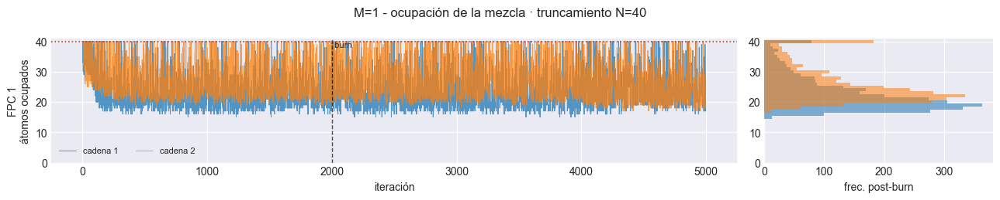

,M,FPC,cadena,media,max,p99,N_trunc,toca_truncamiento
0,1,1,1,22.58,40,40.0,40,True
1,1,1,2,25.72,40,40.0,40,True


! [M=1] alguna cadena alcanza N: el truncamiento está mordiendo. Subir mcmc_config['N'].


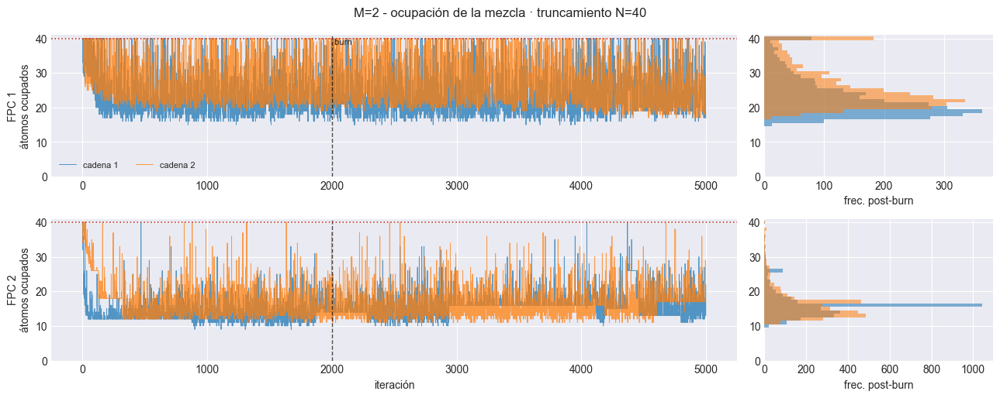

,M,FPC,cadena,media,max,p99,N_trunc,toca_truncamiento
0,2,1,1,22.58,40,40.0,40,True
1,2,1,2,25.72,40,40.0,40,True
2,2,2,1,15.94,40,27.0,40,True
3,2,2,2,16.05,40,33.0,40,True


! [M=2] alguna cadena alcanza N: el truncamiento está mordiendo. Subir mcmc_config['N'].


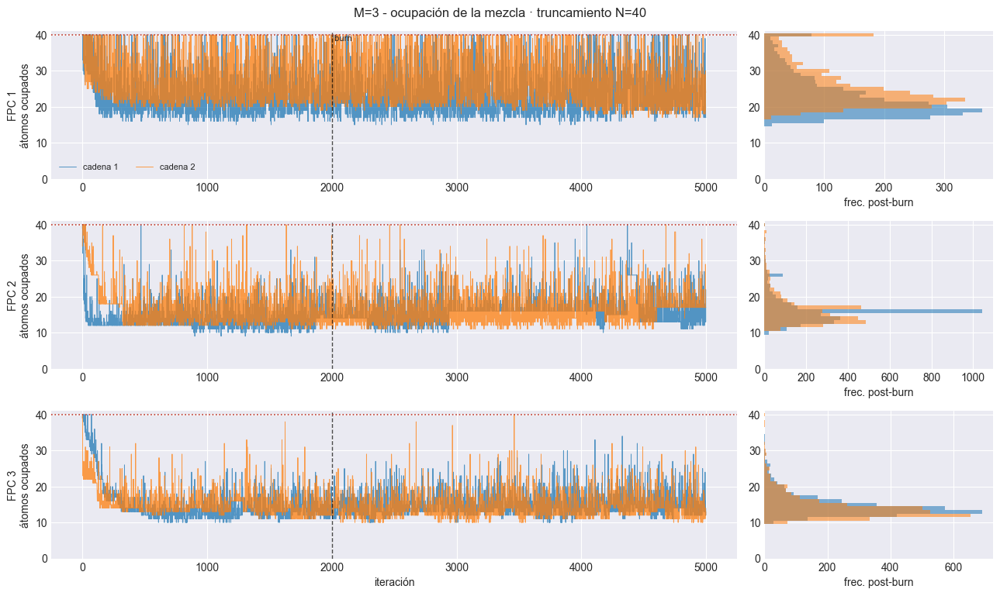

,M,FPC,cadena,media,max,p99,N_trunc,toca_truncamiento
0,3,1,1,22.58,40,40.0,40,True
1,3,1,2,25.72,40,40.0,40,True
2,3,2,1,15.94,40,27.0,40,True
3,3,2,2,16.05,40,33.0,40,True
4,3,3,1,14.64,34,26.0,40,False
5,3,3,2,14.08,40,25.0,40,True


! [M=3] alguna cadena alcanza N: el truncamiento está mordiendo. Subir mcmc_config['N'].


In [9]:
for M in M_OK:
    e = EST[M]
    ci, n_comp = e["component_idx"], e["n_components"]
    N_ATOMOS, BURN = e["n_atomos"], e["burn"]

    fig, axes = plt.subplots(n_comp, 2, figsize=(13, 2.6 * n_comp),
                             squeeze=False, gridspec_kw={"width_ratios": [3, 1]})
    resumen_ocupacion = []

    for k in range(n_comp):
        ax_tr, ax_hi = axes[k]
        for c in sorted(e["models_chains"][k]):
            n1 = e["models_chains"][k][c].traces["N1out"]
            ax_tr.plot(np.arange(len(n1)), n1, lw=0.7, alpha=0.75,
                       label=f"cadena {c+1}")
            ax_hi.hist(n1[BURN:], bins=np.arange(0.5, N_ATOMOS + 1.5), alpha=0.55,
                       orientation="horizontal")
            post = n1[BURN:]
            resumen_ocupacion.append({
                "M": M, "FPC": ci[k] + 1, "cadena": c + 1,
                "media": post.mean(), "max": int(post.max()),
                "p99": float(np.quantile(post, 0.99)), "N_trunc": N_ATOMOS,
                "toca_truncamiento": bool(post.max() >= N_ATOMOS),
            })
        ax_tr.axvline(BURN, color="k", ls="--", lw=1, alpha=0.7)
        ax_tr.axhline(N_ATOMOS, color="#c0392b", ls=":", lw=1.2)
        ax_tr.set_ylabel(f"FPC {ci[k]+1}\nátomos ocupados")
        ax_tr.set_ylim(0, N_ATOMOS + 1)
        ax_hi.set_ylim(0, N_ATOMOS + 1)
        ax_hi.set_xlabel("frec. post-burn")
        if k == 0:
            ax_tr.legend(fontsize=8, ncol=3)
            ax_tr.text(BURN, N_ATOMOS, " burn", fontsize=8, va="top")
    axes[-1, 0].set_xlabel("iteración")
    fig.suptitle(f"M={M} - ocupación de la mezcla · truncamiento N={N_ATOMOS}",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(e["paths"]["out_report"] / "41_ocupacion_mezcla.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    ocup_df = pd.DataFrame(resumen_ocupacion)
    e["ocup_df"] = ocup_df
    display(ocup_df.style.format({"media": "{:.2f}", "p99": "{:.1f}"})
            .set_caption(f"M={M} - átomos ocupados post-calentamiento"))
    if ocup_df["toca_truncamiento"].any():
        print(f"! [M={M}] alguna cadena alcanza N: el truncamiento está "
              "mordiendo. Subir mcmc_config['N'].")
    else:
        print(f"OK [M={M}] ninguna cadena alcanza N={N_ATOMOS}: el truncamiento "
              "no restringe.")

### 4.1 Gating: $\psi$, $\alpha$, $\Gamma$

Diagnóstico de los parámetros de los pesos $\pi_h(x)$. Las variables son promedios ponderados por el peso medio de cada átomo, $\bar w_h=\frac1n\sum_i\pi_h(x_i)$, para que no dependan del etiquetado de la mezcla.

- **átomos ef. global / por punto:** $1/\sum_h\bar w_h^2$ y $\frac1n\sum_i 1/\sum_h\pi_h(x_i)^2$.
- **señal de gating:** global menos por punto. Vale ≈ 0 si los pesos son los mismos en todo $x$.
- **sd del argumento:** dispersión en $i$ de $\alpha_h-\sum_j\psi_{hj}|x_{ij}-\Gamma_{hj}|$, contra el `sd_gate_objetivo` del prior.
- **alpha, psi_j, Gamma_j:** promedios ponderados sobre los $N-1$ palos.

R-hat, ESS y Geweke salen de `diagnostico_variable`.

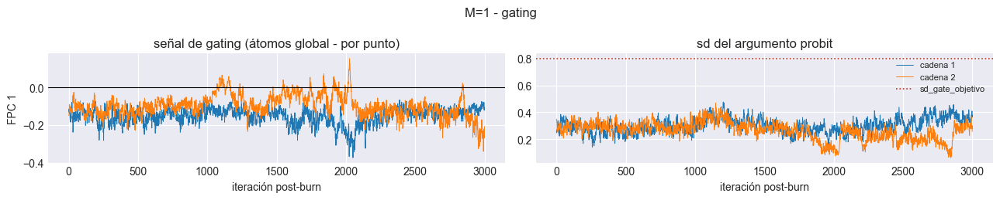

,M,FPC,variable,media_c1,media_c2,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,1,1,atomos_global,1.804,2.180,2,3000,11,14,1.706,1.199,False
1,1,1,atomos_punto,1.956,2.276,2,3000,11,14,1.712,1.152,False
2,1,1,senal_gating,-0.151,-0.096,2,3000,12,16,0.679,1.261,False
3,1,1,sd_argumento,0.301,0.262,2,3000,7,11,5.075,1.097,False
4,1,1,alpha,0.872,0.697,2,3000,11,12,2.538,1.156,False
5,1,1,psi_0,1.013,1.014,2,3000,6,14,5.063,1.000,False
6,1,1,psi_1,0.396,0.156,2,3000,10,43,3.890,1.177,False
7,1,1,psi_2,0.000,0.002,2,3000,7,1285,4.582,1.090,False
8,1,1,psi_3,0.006,0.072,2,3000,4,8,4.975,1.759,False
9,1,1,psi_4,0.002,0.004,2,3000,8,9,3.639,1.050,False


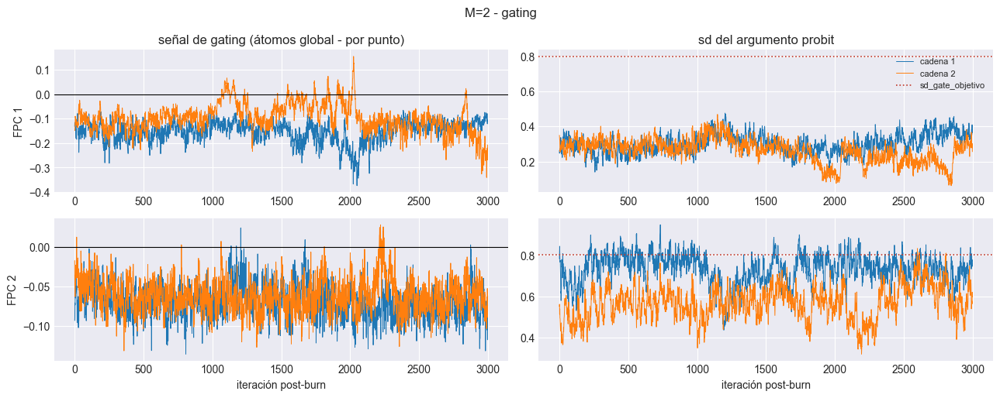

,M,FPC,variable,media_c1,media_c2,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,2,1,atomos_global,1.804,2.180,2,3000,11,14,1.706,1.199,False
1,2,1,atomos_punto,1.956,2.276,2,3000,11,14,1.712,1.152,False
2,2,1,senal_gating,-0.151,-0.096,2,3000,12,16,0.679,1.261,False
3,2,1,sd_argumento,0.301,0.262,2,3000,7,11,5.075,1.097,False
4,2,1,alpha,0.872,0.697,2,3000,11,12,2.538,1.156,False
5,2,1,psi_0,1.013,1.014,2,3000,6,14,5.063,1.000,False
6,2,1,psi_1,0.396,0.156,2,3000,10,43,3.890,1.177,False
7,2,1,psi_2,0.000,0.002,2,3000,7,1285,4.582,1.090,False
8,2,1,psi_3,0.006,0.072,2,3000,4,8,4.975,1.759,False
9,2,1,psi_4,0.002,0.004,2,3000,8,9,3.639,1.050,False


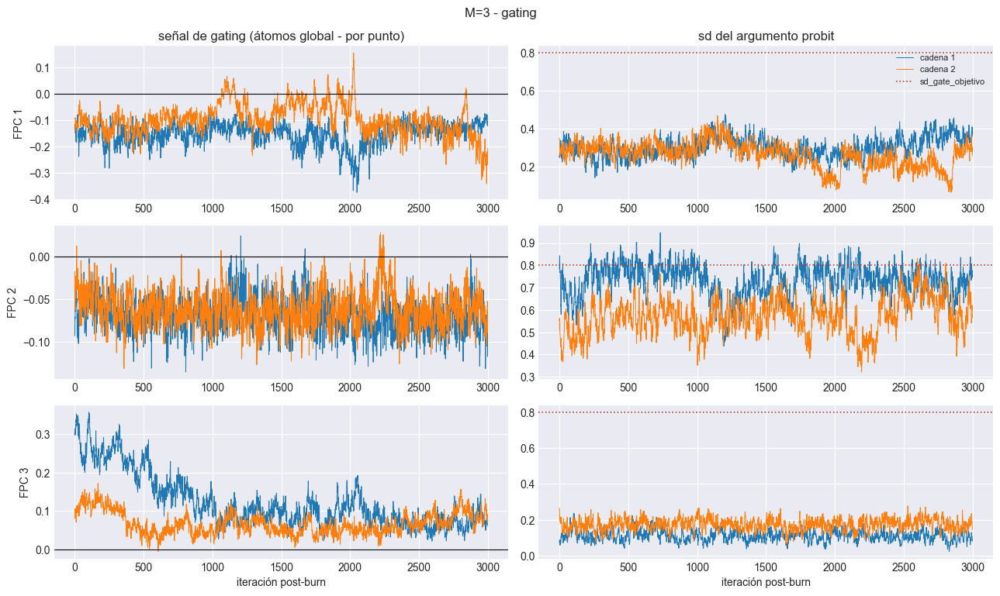

,M,FPC,variable,media_c1,media_c2,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
0,3,1,atomos_global,1.804,2.180,2,3000,11,14,1.706,1.199,False
1,3,1,atomos_punto,1.956,2.276,2,3000,11,14,1.712,1.152,False
2,3,1,senal_gating,-0.151,-0.096,2,3000,12,16,0.679,1.261,False
3,3,1,sd_argumento,0.301,0.262,2,3000,7,11,5.075,1.097,False
4,3,1,alpha,0.872,0.697,2,3000,11,12,2.538,1.156,False
5,3,1,psi_0,1.013,1.014,2,3000,6,14,5.063,1.000,False
6,3,1,psi_1,0.396,0.156,2,3000,10,43,3.890,1.177,False
7,3,1,psi_2,0.000,0.002,2,3000,7,1285,4.582,1.090,False
8,3,1,psi_3,0.006,0.072,2,3000,4,8,4.975,1.759,False
9,3,1,psi_4,0.002,0.004,2,3000,8,9,3.639,1.050,False


In [10]:
from model_psbp_fd.models.pspb_fd_v3 import pesos_probit


def series_gating(mt, X):
    tr, b = mt.traces, mt.burn
    al, ps, gm = tr["alphahout"][b:], tr["psijhout"][b:], tr["Gammajhout"][b:]
    T, p = al.shape[0], X.shape[1]
    nombres = (["atomos_global", "atomos_punto", "senal_gating", "sd_argumento", "alpha"]
               + [f"psi_{j}" for j in range(p)] + [f"Gamma_{j}" for j in range(p)])
    S = {n: np.empty(T) for n in nombres}
    for t in range(T):
        w = pesos_probit(X, al[t], ps[t], gm[t])
        wbar = w.mean(0)
        s = wbar[:-1].sum()
        u = wbar[:-1] / s if s > 1e-12 else np.full(len(wbar) - 1, 1.0 / (len(wbar) - 1))
        eta = al[t][:, None] - np.sum(ps[t][:, None, :] * np.abs(X[None] - gm[t][:, None, :]), axis=2)
        S["atomos_global"][t] = 1.0 / np.sum(wbar ** 2)
        S["atomos_punto"][t] = np.mean(1.0 / np.sum(w ** 2, axis=1))
        S["sd_argumento"][t] = np.sum(u * eta.std(axis=1))
        S["alpha"][t] = np.sum(u * al[t])
        for j in range(p):
            S[f"psi_{j}"][t] = np.sum(u * ps[t][:, j])
            S[f"Gamma_{j}"][t] = np.sum(u * gm[t][:, j])
    S["senal_gating"] = S["atomos_global"] - S["atomos_punto"]
    return S


_CACHE_GATING = {}

for M in M_OK:
    e = EST[M]
    ci, n_comp = e["component_idx"], e["n_components"]
    filas = []
    fig, axes = plt.subplots(n_comp, 2, figsize=(13, 2.6 * n_comp), squeeze=False)

    for k in range(n_comp):
        X = e["dfs_train"][k].iloc[:, 1:].to_numpy()
        cams = sorted(e["models_chains"][k])
        for c in cams:
            if (ci[k], c) not in _CACHE_GATING:
                _CACHE_GATING[(ci[k], c)] = series_gating(e["models_chains"][k][c], X)
        SER = {c: _CACHE_GATING[(ci[k], c)] for c in cams}
        obj = e["hp_json"].get("escalera", {}).get(str(k), {}).get("sd_gate_objetivo")

        for v in SER[cams[0]]:
            C = np.vstack([SER[c][v] for c in cams])
            fila = {"M": M, "FPC": ci[k] + 1, "variable": v}
            fila.update({f"media_c{c+1}": SER[c][v].mean() for c in cams})
            fila.update(diagnostico_variable(C))
            filas.append(fila)

        for c in cams:
            axes[k, 0].plot(SER[c]["senal_gating"], lw=0.7, label=f"cadena {c+1}")
            axes[k, 1].plot(SER[c]["sd_argumento"], lw=0.7, label=f"cadena {c+1}")
        axes[k, 0].axhline(0, color="k", lw=0.8)
        if obj is not None:
            axes[k, 1].axhline(obj, color="#c0392b", ls=":", lw=1.2, label="sd_gate_objetivo")
        axes[k, 0].set_ylabel(f"FPC {ci[k]+1}")
        if k == 0:
            axes[k, 0].set_title("señal de gating (átomos global - por punto)")
            axes[k, 1].set_title("sd del argumento probit")
            axes[k, 1].legend(fontsize=8)
    axes[-1, 0].set_xlabel("iteración post-burn")
    axes[-1, 1].set_xlabel("iteración post-burn")
    fig.suptitle(f"M={M} - gating", fontsize=12)
    fig.tight_layout()
    fig.savefig(e["paths"]["out_report"] / "49_gating.png", dpi=150, bbox_inches="tight")
    plt.show()

    gat = pd.DataFrame(filas)
    gat.to_csv(e["paths"]["out_report"] / "48_gating_diagnosticos.csv", index=False)
    e["gating_df"] = gat
    display(gat.style.format({c: "{:.3f}" for c in gat.columns
                              if c.startswith("media_") or c in ("rhat", "geweke_max")}
                             | {"ess_min": "{:.0f}", "ess_mean": "{:.0f}"})
            .set_caption(f"M={M} - gating post-calentamiento"))

## 5. Figuras de convergencia por parámetro

== M=1 ==============================================


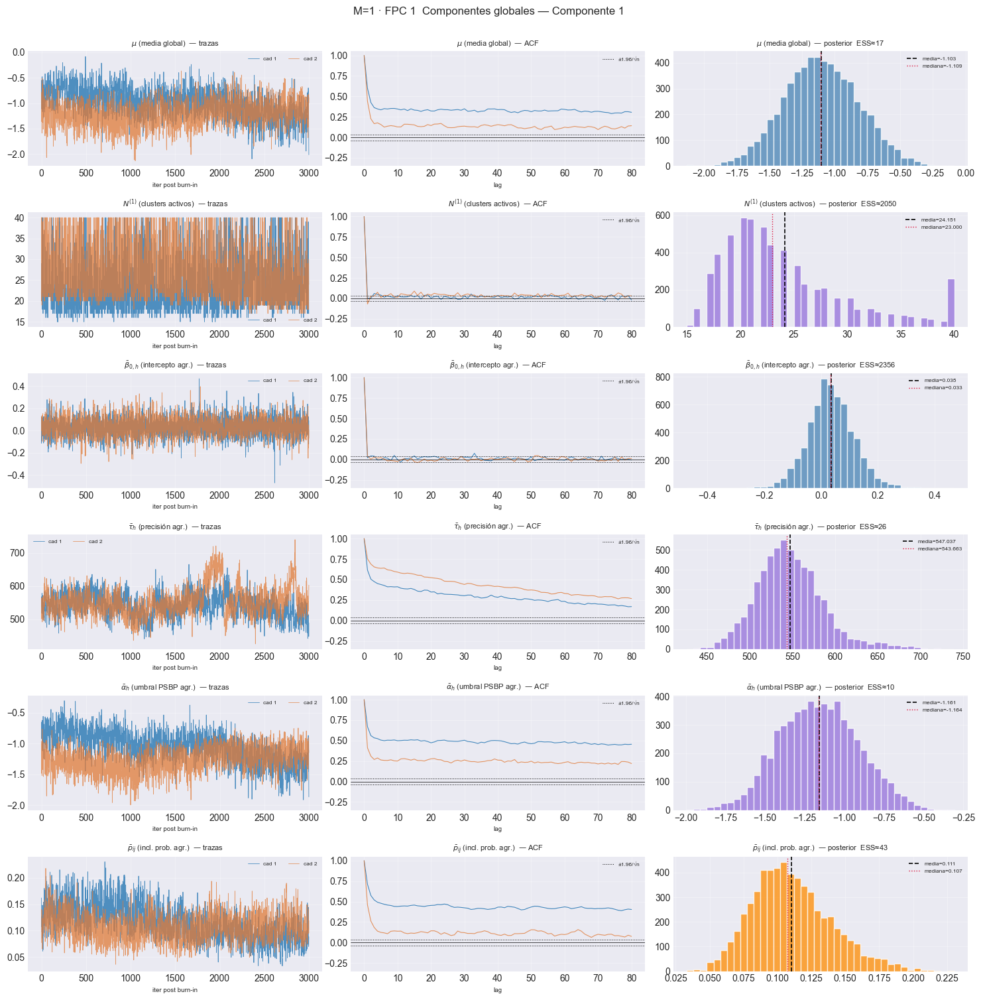

C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_global_components.py:276: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_global_components.py:278: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


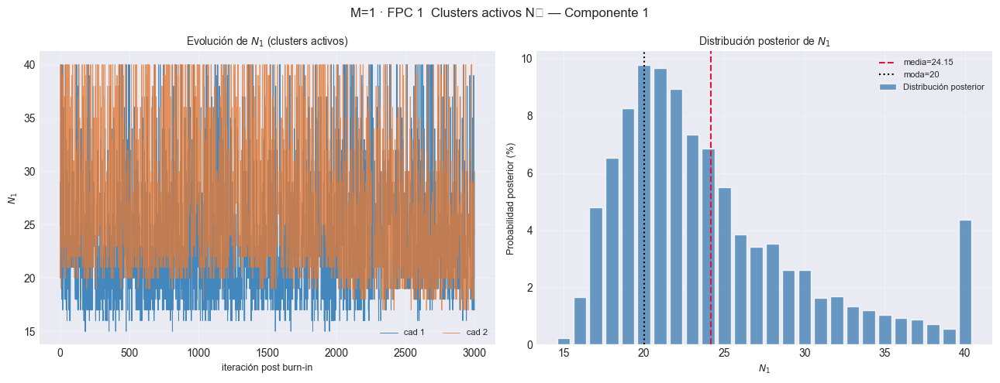

== M=2 ==============================================


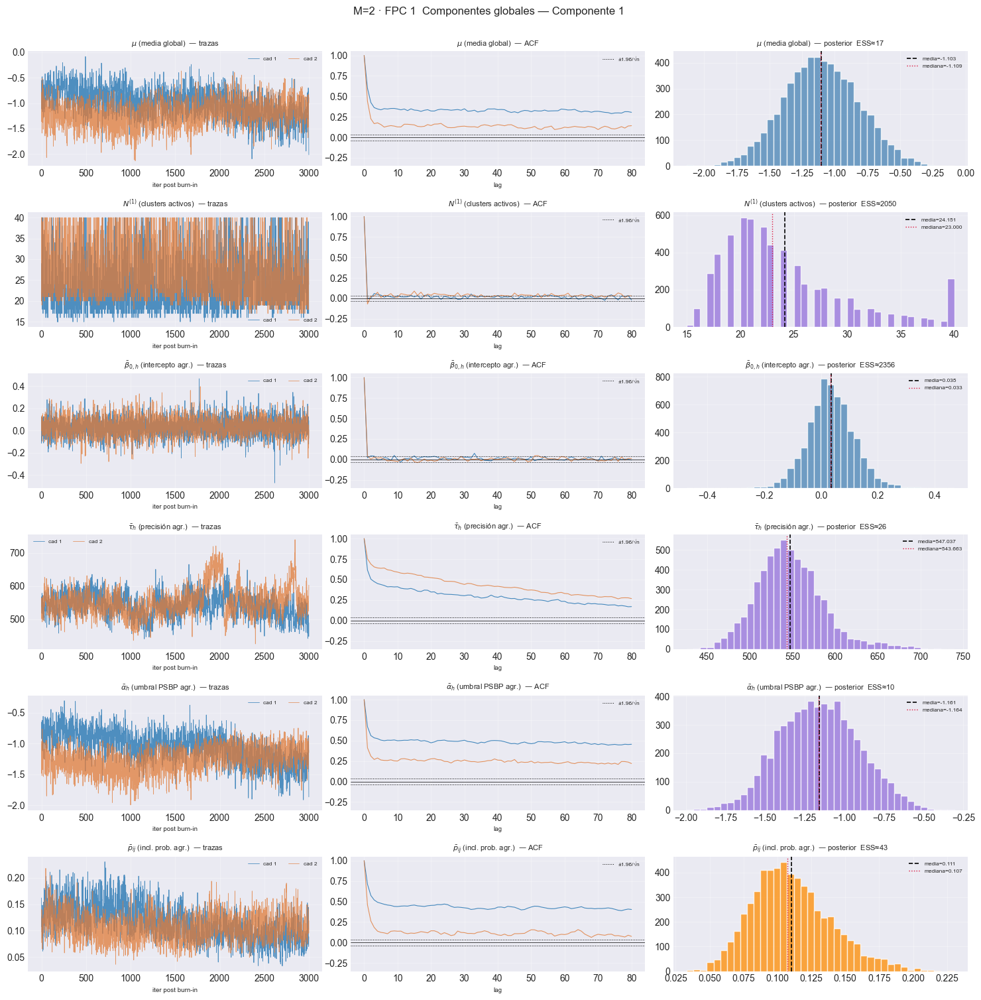

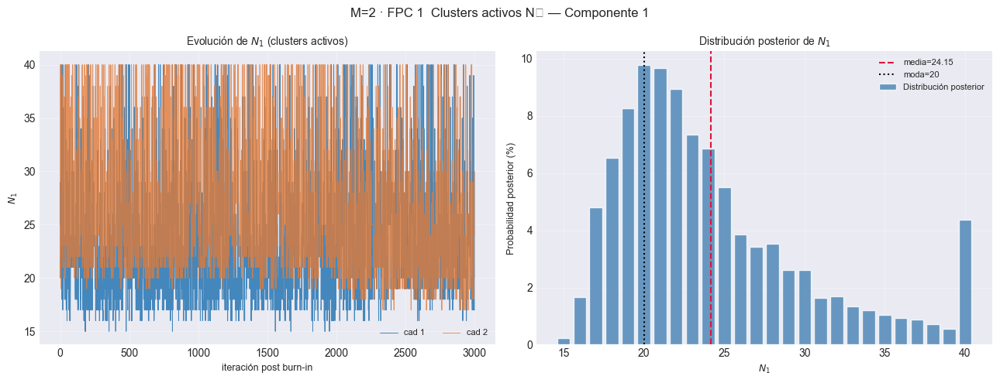

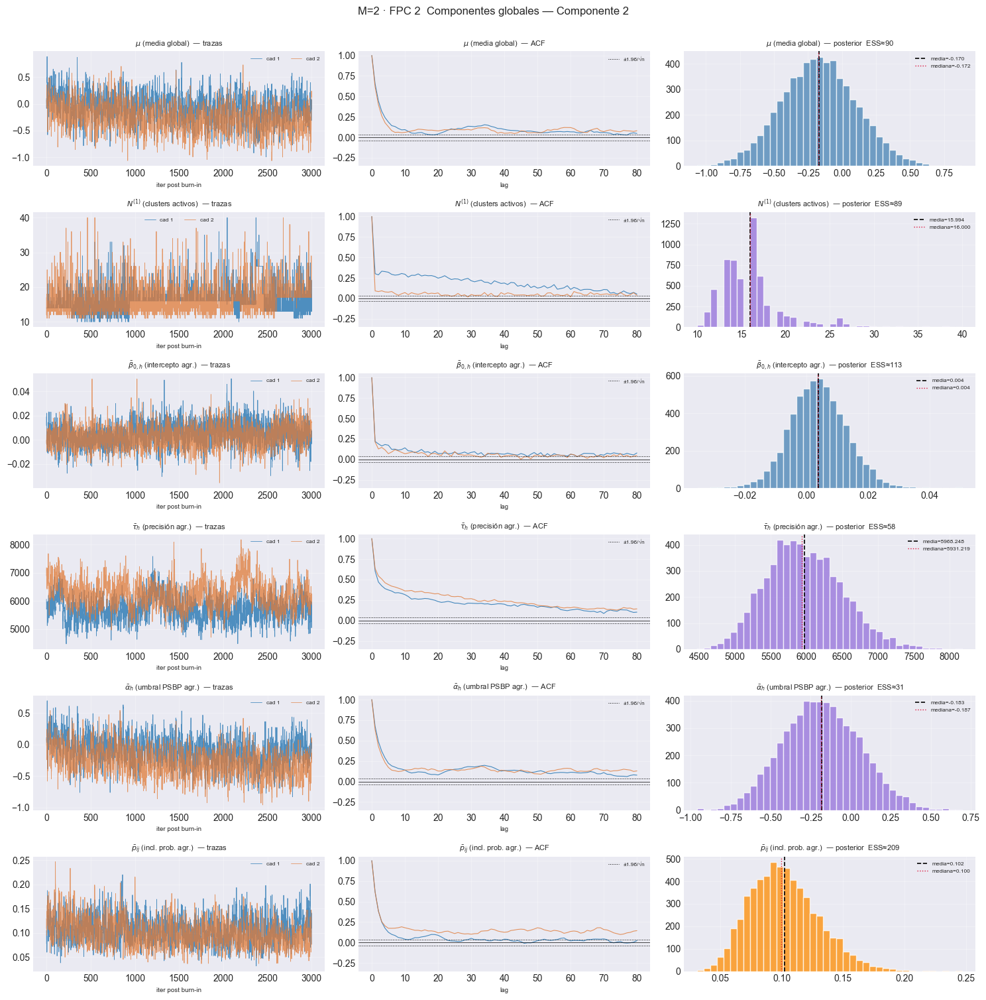

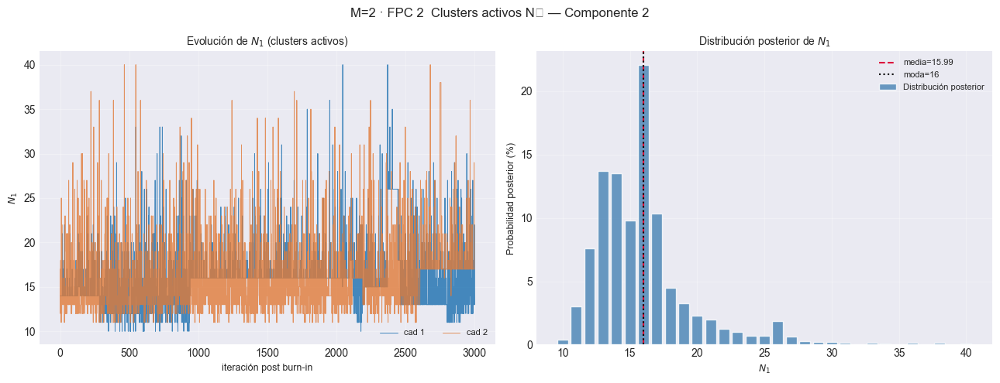

== M=3 ==============================================


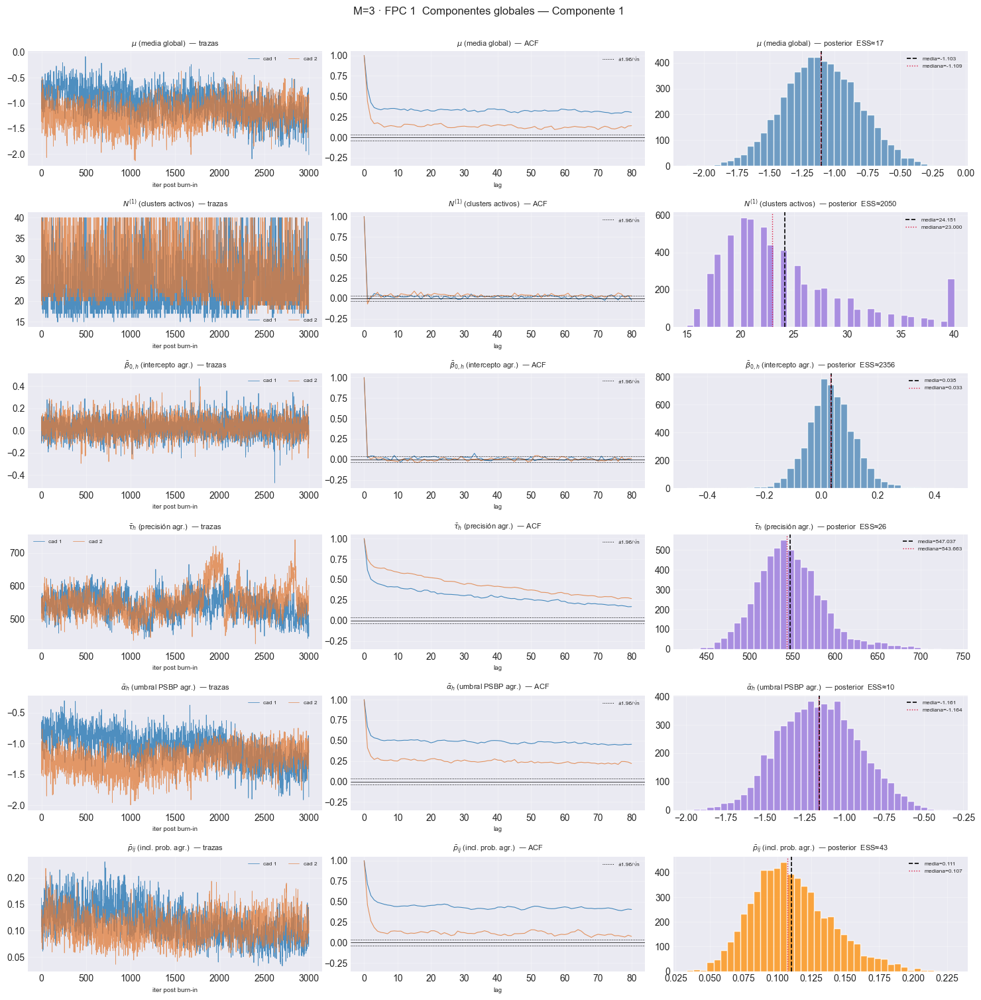

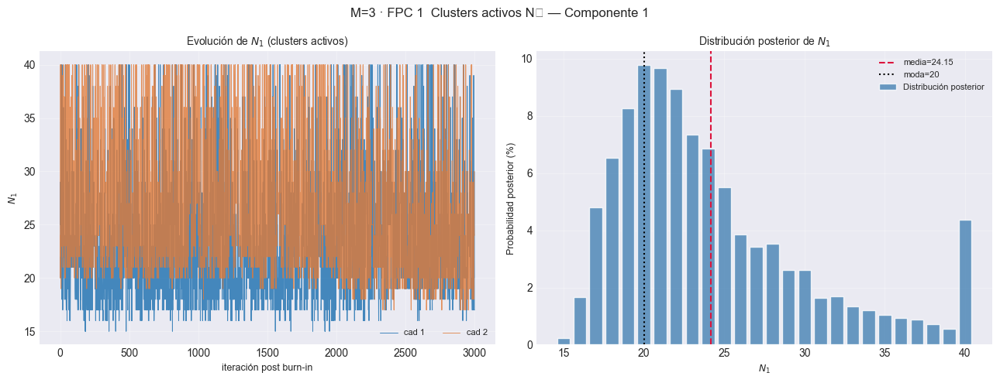

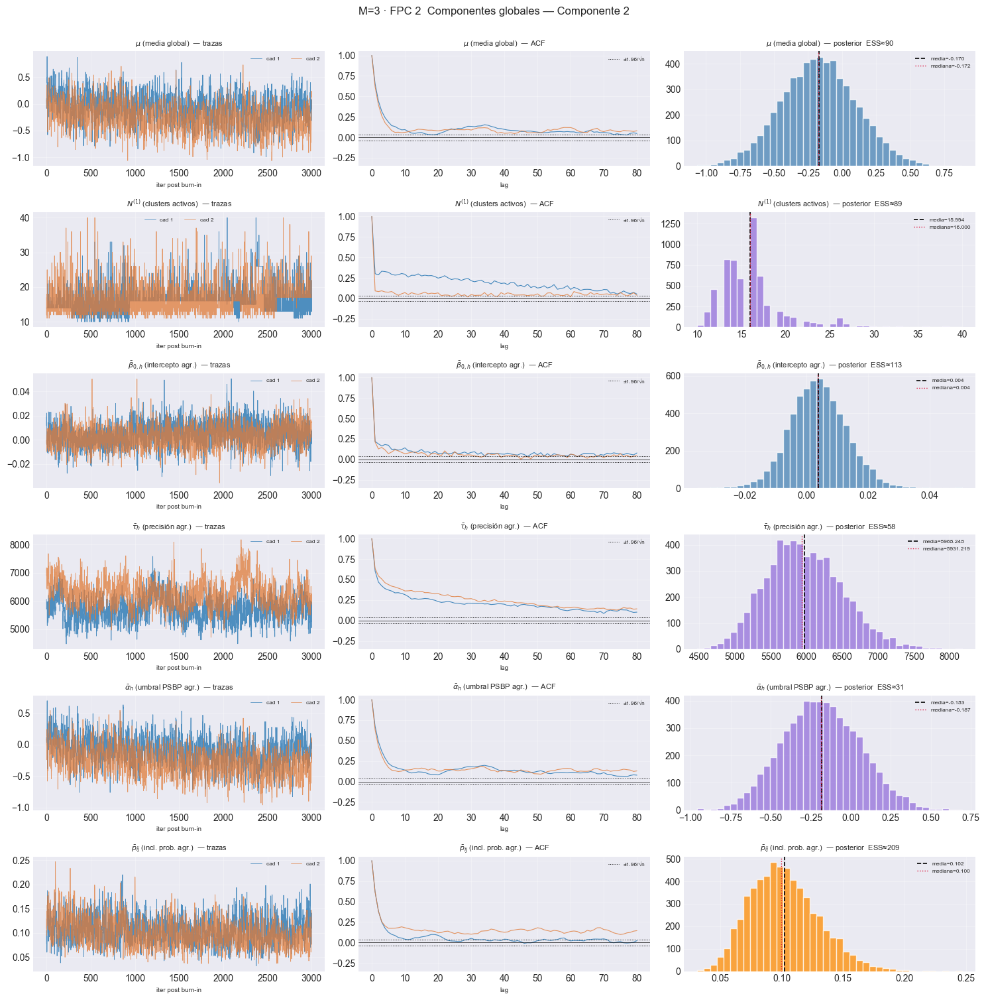

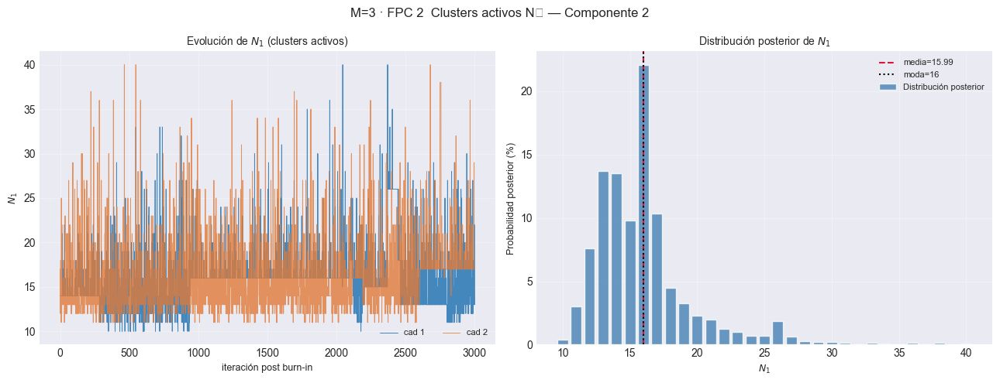

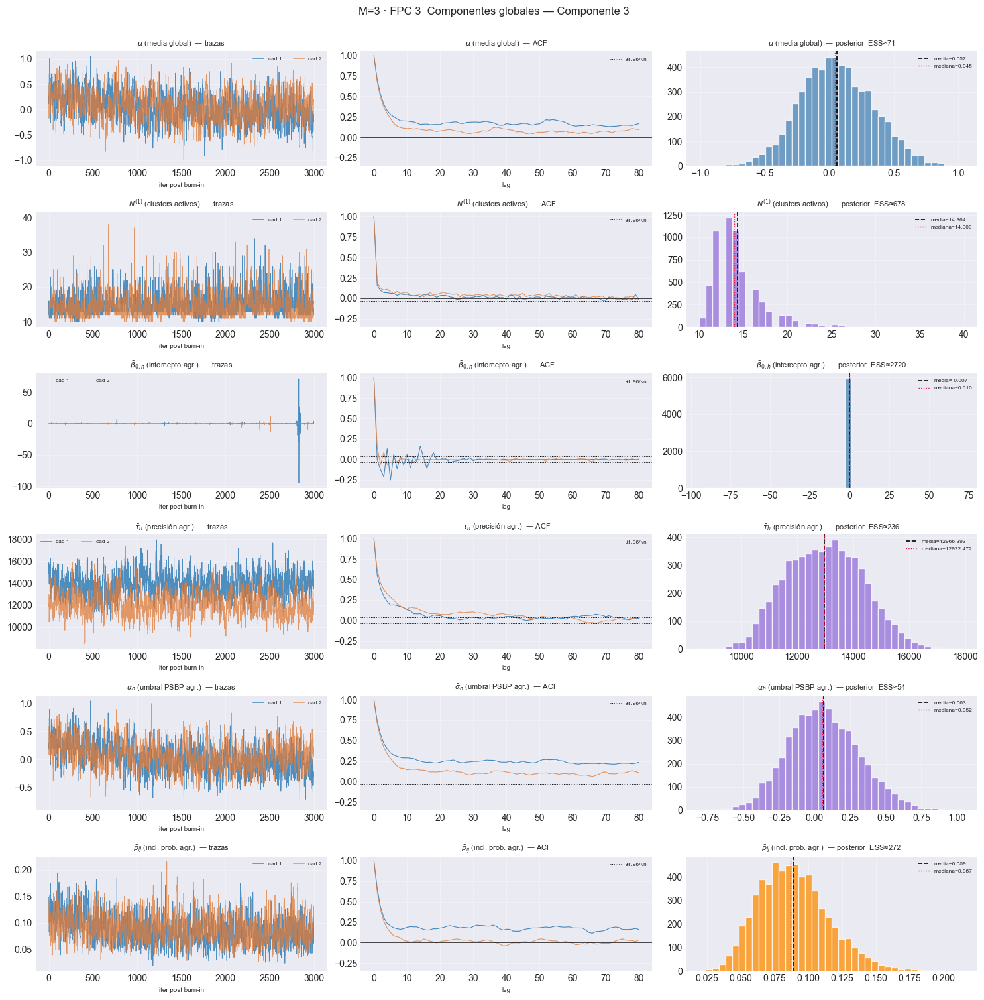

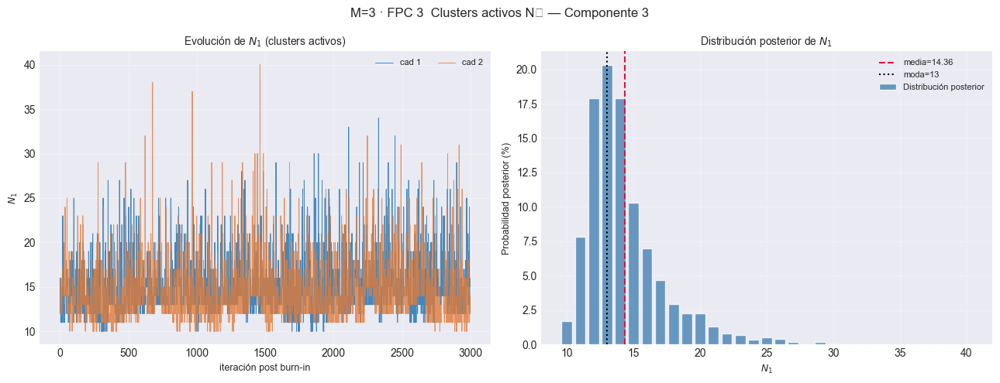

In [11]:
for M in M_OK:
    e = EST[M]
    print(f"== M={M} " + "=" * 46)
    for k in e["models_chains"]:
        fpc = e["component_idx"][k] + 1
        plot_global_components(
            e["models_chains"], k, e["burn"], e["n_iter"],
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"42_global_k{fpc}.png"))
        plt.show()
        plot_active_clusters(
            e["models_chains"], k, e["burn"], e["n_iter"],
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"43_clusters_k{fpc}.png"))
        plt.show()

== M=1 ==============================================
[plot_convergence_bj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.5s  fpc_1_lag1  rhat=1.002  ess_min=2383  |G|=2.17  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_1_lag2  rhat=1.001  ess_min=1661  |G|=2.56  ✗
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_1_lag3  rhat=1.000  ess_min=2897  |G|=1.48  ✓
  4/7 (57.1%) t=0.3s eta=0.2s  fpc_1_lag4  rhat=1.000  ess_min=2313  |G|=1.01  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_1_lag5  rhat=1.001  ess_min=2039  |G|=2.28  ✗
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_1_lag6  rhat=1.000  ess_min=3000  |G|=1.67  ✓
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_1_lag7  rhat=1.000  ess_min=2421  |G|=1.19  ✓


C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:348: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:348: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:350: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:350: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


[plot_convergence_bj[FPC 1]] listo: 7 pasos en 4.5s  3/7 sin converger


c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


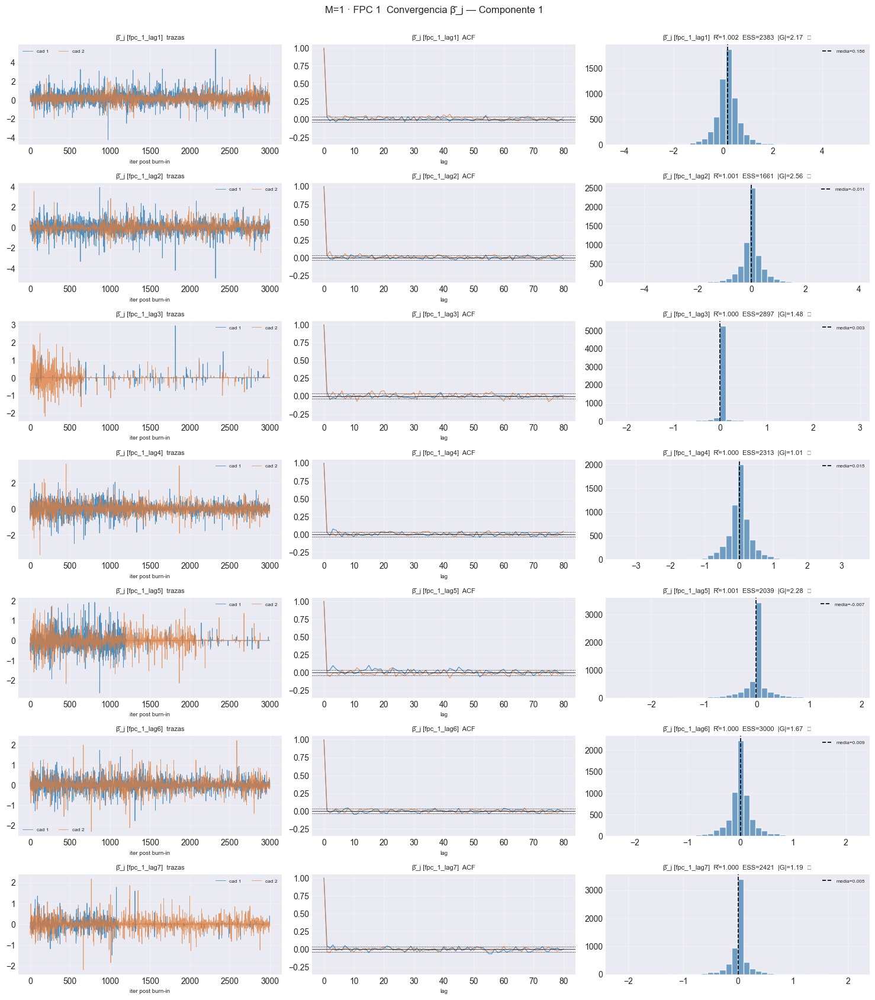

[plot_convergence_pj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.180  ess_min=10  |G|=2.18  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_1_lag2  rhat=1.165  ess_min=9  |G|=10.50  ✗
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_1_lag3  rhat=1.061  ess_min=8  |G|=18.13  ✗
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_1_lag4  rhat=1.093  ess_min=39  |G|=1.83  ✗
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_1_lag5  rhat=1.038  ess_min=7  |G|=15.22  ✗
  6/7 (85.7%) t=0.3s eta=0.1s  fpc_1_lag6  rhat=1.050  ess_min=32  |G|=4.21  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_1_lag7  rhat=1.126  ess_min=6  |G|=11.12  ✗


C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:447: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:449: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


[plot_convergence_pj[FPC 1]] listo: 7 pasos en 4.9s  7/7 sin converger


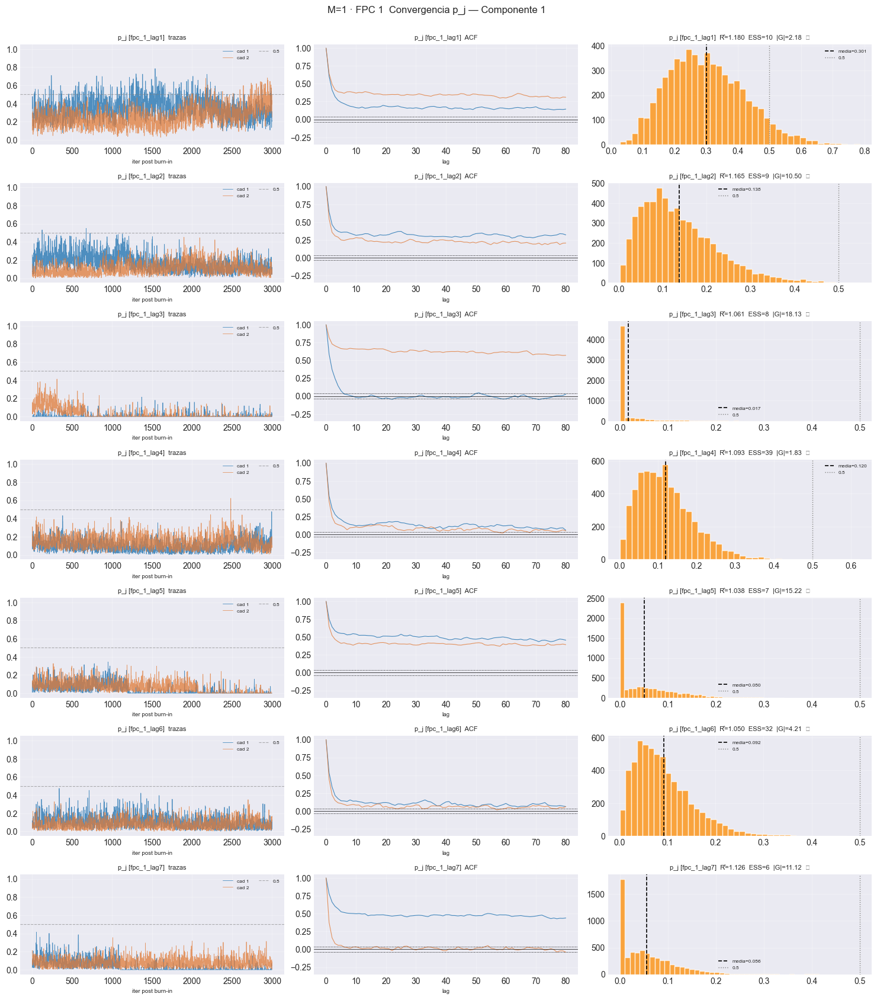

== M=2 ==============================================
[plot_convergence_bj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.002  ess_min=2383  |G|=2.17  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_1_lag2  rhat=1.001  ess_min=1661  |G|=2.56  ✗
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_1_lag3  rhat=1.000  ess_min=2897  |G|=1.48  ✓
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_1_lag4  rhat=1.000  ess_min=2313  |G|=1.01  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_1_lag5  rhat=1.001  ess_min=2039  |G|=2.28  ✗
  6/7 (85.7%) t=0.3s eta=0.1s  fpc_1_lag6  rhat=1.000  ess_min=3000  |G|=1.67  ✓
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_1_lag7  rhat=1.000  ess_min=2421  |G|=1.19  ✓
[plot_convergence_bj[FPC 1]] listo: 7 pasos en 4.2s  3/7 sin converger


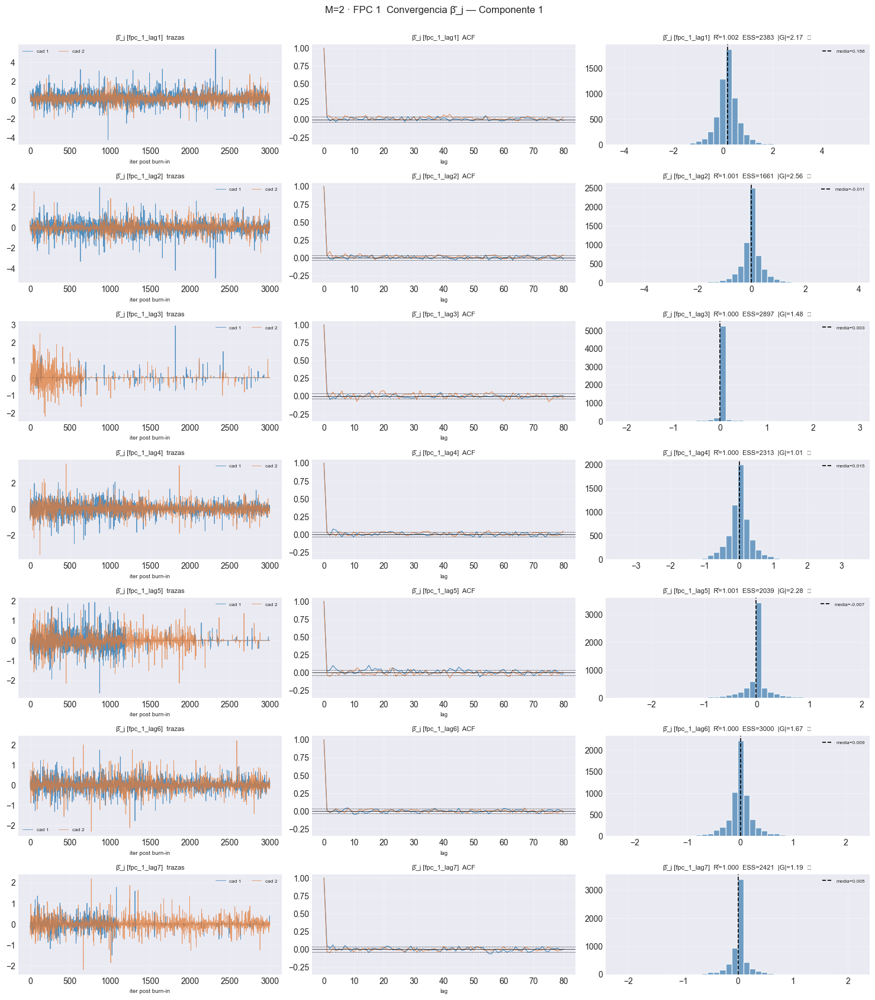

[plot_convergence_pj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.180  ess_min=10  |G|=2.18  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_1_lag2  rhat=1.165  ess_min=9  |G|=10.50  ✗
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_1_lag3  rhat=1.061  ess_min=8  |G|=18.13  ✗
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_1_lag4  rhat=1.093  ess_min=39  |G|=1.83  ✗
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_1_lag5  rhat=1.038  ess_min=7  |G|=15.22  ✗
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_1_lag6  rhat=1.050  ess_min=32  |G|=4.21  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_1_lag7  rhat=1.126  ess_min=6  |G|=11.12  ✗
[plot_convergence_pj[FPC 1]] listo: 7 pasos en 4.4s  7/7 sin converger


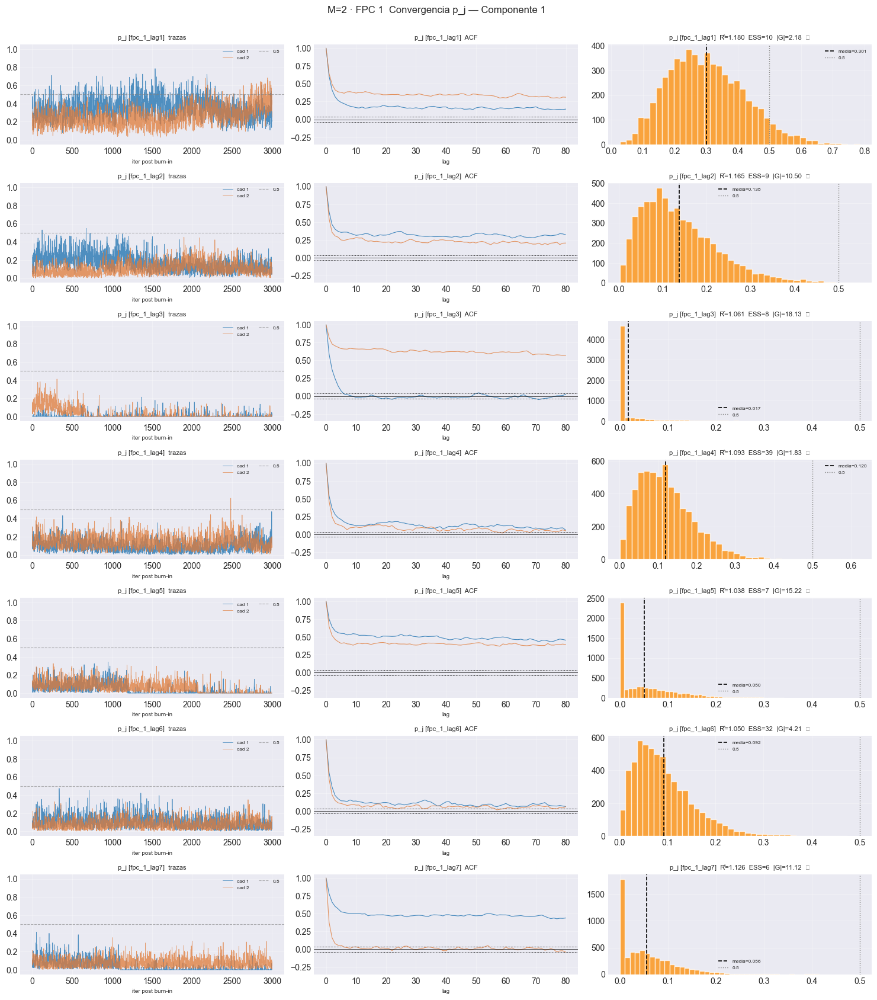

[plot_convergence_bj[FPC 2]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_2_lag1  rhat=1.001  ess_min=2793  |G|=0.99  ✓
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_2_lag2  rhat=1.019  ess_min=2445  |G|=1.21  ✓
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_2_lag3  rhat=1.017  ess_min=1865  |G|=0.47  ✓
  4/7 (57.1%) t=0.3s eta=0.2s  fpc_2_lag4  rhat=1.026  ess_min=2459  |G|=1.84  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_2_lag5  rhat=1.000  ess_min=2555  |G|=1.09  ✓
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_2_lag6  rhat=1.068  ess_min=42  |G|=0.76  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_2_lag7  rhat=1.001  ess_min=220  |G|=5.27  ✗
[plot_convergence_bj[FPC 2]] listo: 7 pasos en 5.2s  2/7 sin converger


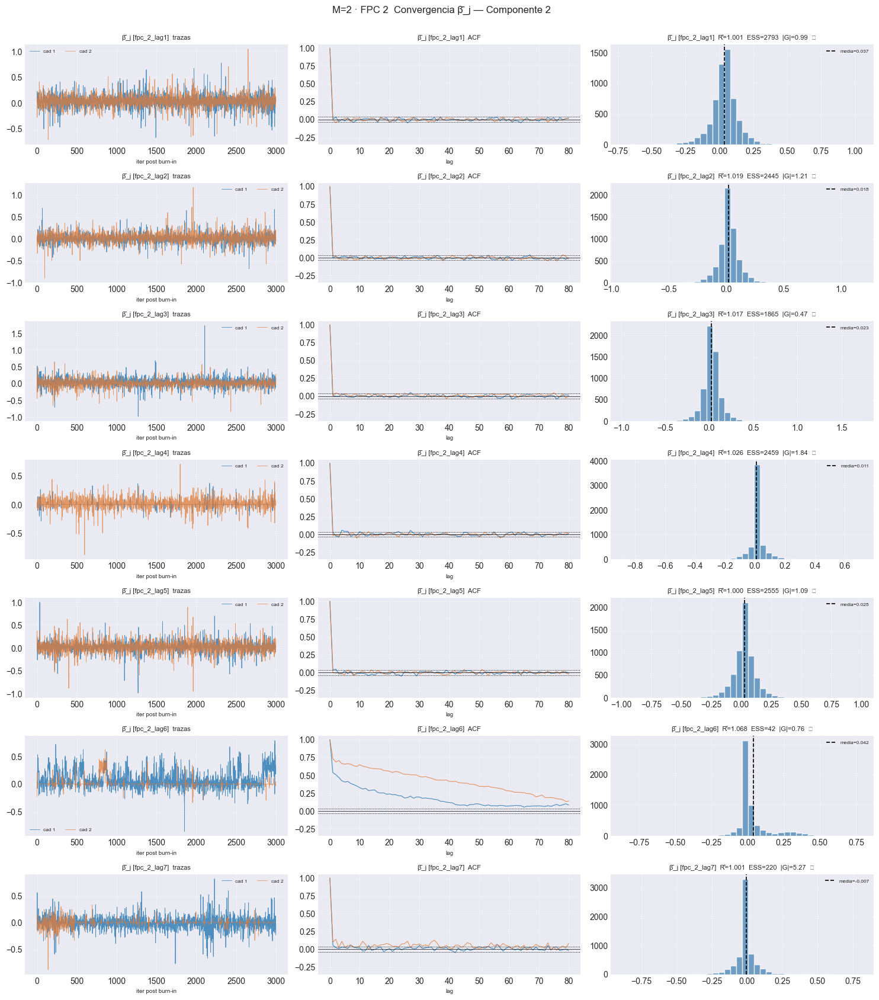

[plot_convergence_pj[FPC 2]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_2_lag1  rhat=1.004  ess_min=367  |G|=1.04  ✓
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_2_lag2  rhat=1.094  ess_min=910  |G|=2.01  ✗
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_2_lag3  rhat=1.062  ess_min=30  |G|=6.30  ✗
  4/7 (57.1%) t=0.3s eta=0.2s  fpc_2_lag4  rhat=1.542  ess_min=362  |G|=0.84  ✗
  5/7 (71.4%) t=0.4s eta=0.1s  fpc_2_lag5  rhat=1.088  ess_min=789  |G|=2.48  ✗
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_2_lag6  rhat=1.545  ess_min=95  |G|=1.35  ✗
  7/7 (100.0%) t=0.5s eta=0.0s  fpc_2_lag7  rhat=1.346  ess_min=14  |G|=12.53  ✗


C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:447: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\model_psbp_fd\graphics\viz_traces.py:449: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=150, bbox_inches="tight")


[plot_convergence_pj[FPC 2]] listo: 7 pasos en 5.4s  6/7 sin converger


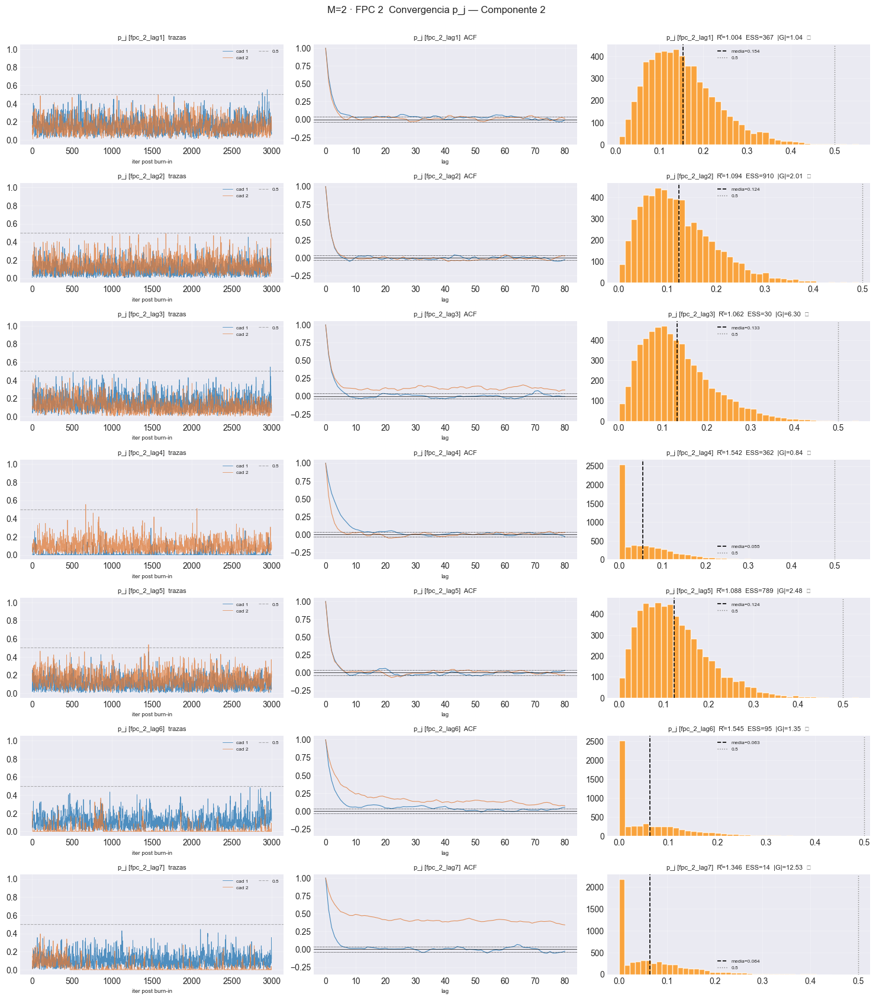

== M=3 ==============================================
[plot_convergence_bj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.002  ess_min=2383  |G|=2.17  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_1_lag2  rhat=1.001  ess_min=1661  |G|=2.56  ✗
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_1_lag3  rhat=1.000  ess_min=2897  |G|=1.48  ✓
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_1_lag4  rhat=1.000  ess_min=2313  |G|=1.01  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_1_lag5  rhat=1.001  ess_min=2039  |G|=2.28  ✗
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_1_lag6  rhat=1.000  ess_min=3000  |G|=1.67  ✓
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_1_lag7  rhat=1.000  ess_min=2421  |G|=1.19  ✓
[plot_convergence_bj[FPC 1]] listo: 7 pasos en 4.4s  3/7 sin converger


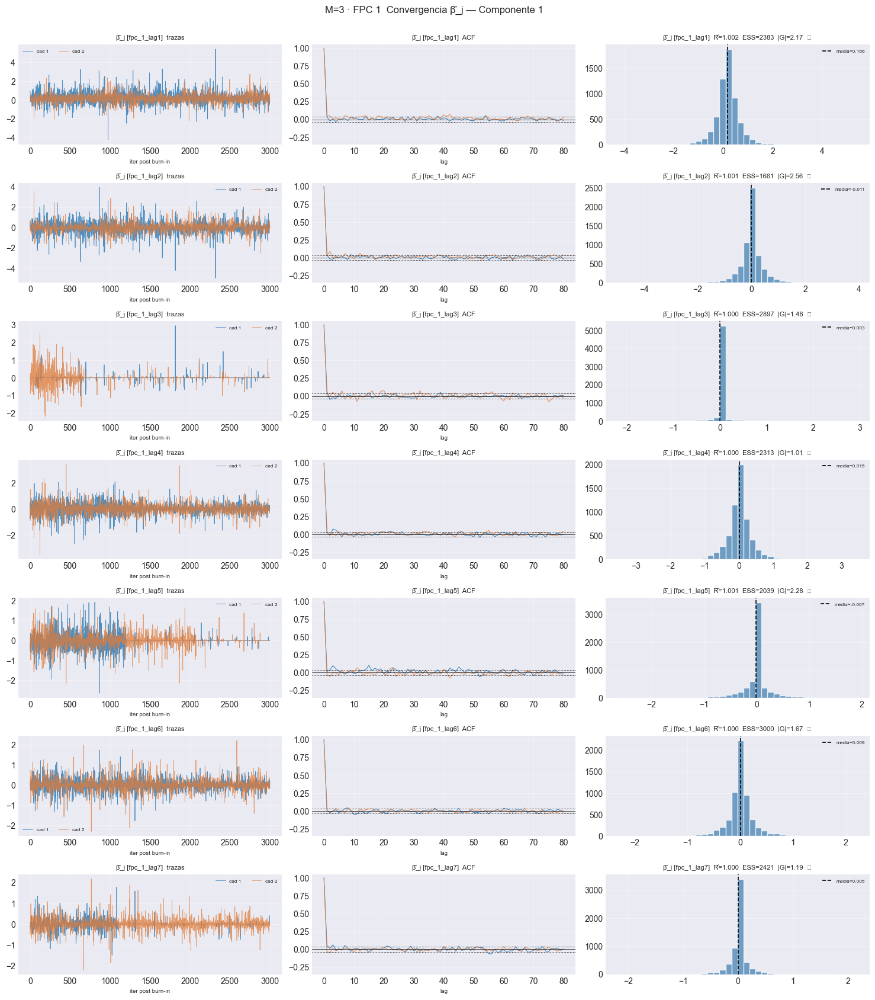

[plot_convergence_pj[FPC 1]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_1_lag1  rhat=1.180  ess_min=10  |G|=2.18  ✗
  2/7 (28.6%) t=0.1s eta=0.4s  fpc_1_lag2  rhat=1.165  ess_min=9  |G|=10.50  ✗
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_1_lag3  rhat=1.061  ess_min=8  |G|=18.13  ✗
  4/7 (57.1%) t=0.3s eta=0.2s  fpc_1_lag4  rhat=1.093  ess_min=39  |G|=1.83  ✗
  5/7 (71.4%) t=0.4s eta=0.1s  fpc_1_lag5  rhat=1.038  ess_min=7  |G|=15.22  ✗
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_1_lag6  rhat=1.050  ess_min=32  |G|=4.21  ✗
  7/7 (100.0%) t=0.5s eta=0.0s  fpc_1_lag7  rhat=1.126  ess_min=6  |G|=11.12  ✗
[plot_convergence_pj[FPC 1]] listo: 7 pasos en 4.8s  7/7 sin converger


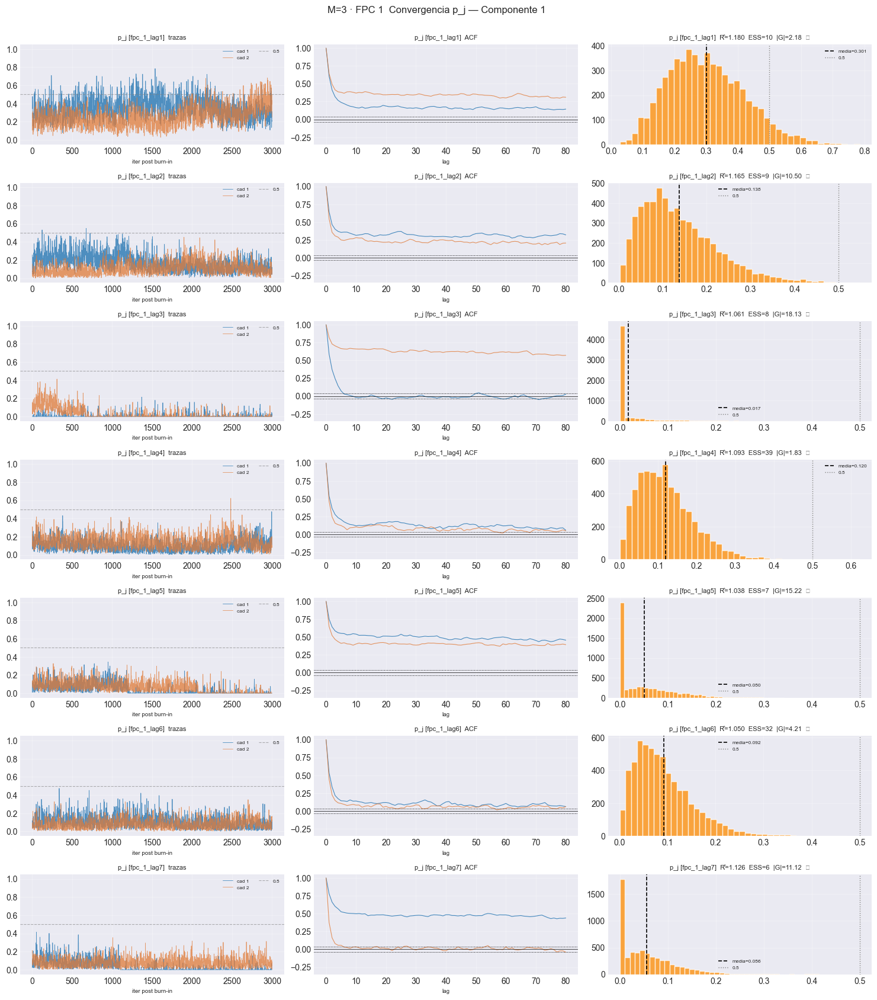

[plot_convergence_bj[FPC 2]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_2_lag1  rhat=1.001  ess_min=2793  |G|=0.99  ✓
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_2_lag2  rhat=1.019  ess_min=2445  |G|=1.21  ✓
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_2_lag3  rhat=1.017  ess_min=1865  |G|=0.47  ✓
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_2_lag4  rhat=1.026  ess_min=2459  |G|=1.84  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_2_lag5  rhat=1.000  ess_min=2555  |G|=1.09  ✓
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_2_lag6  rhat=1.068  ess_min=42  |G|=0.76  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_2_lag7  rhat=1.001  ess_min=220  |G|=5.27  ✗
[plot_convergence_bj[FPC 2]] listo: 7 pasos en 4.5s  2/7 sin converger


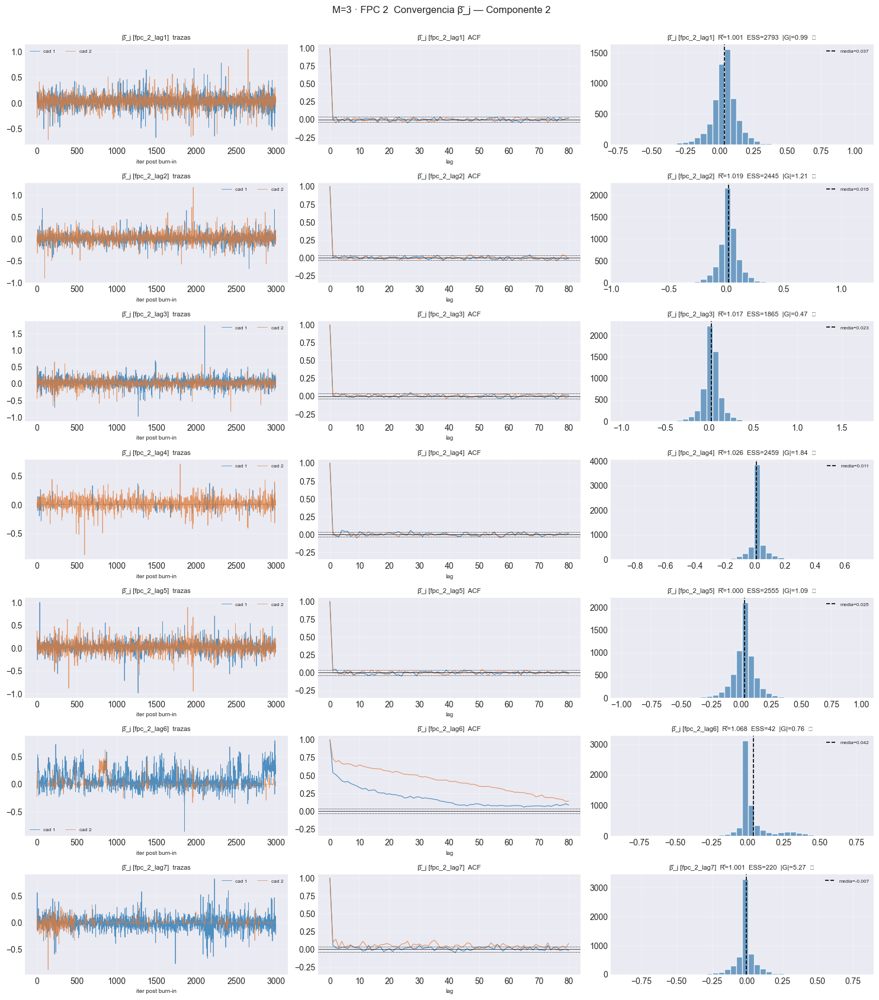

[plot_convergence_pj[FPC 2]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_2_lag1  rhat=1.004  ess_min=367  |G|=1.04  ✓
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_2_lag2  rhat=1.094  ess_min=910  |G|=2.01  ✗
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_2_lag3  rhat=1.062  ess_min=30  |G|=6.30  ✗
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_2_lag4  rhat=1.542  ess_min=362  |G|=0.84  ✗
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_2_lag5  rhat=1.088  ess_min=789  |G|=2.48  ✗
  6/7 (85.7%) t=0.3s eta=0.1s  fpc_2_lag6  rhat=1.545  ess_min=95  |G|=1.35  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_2_lag7  rhat=1.346  ess_min=14  |G|=12.53  ✗
[plot_convergence_pj[FPC 2]] listo: 7 pasos en 4.9s  6/7 sin converger


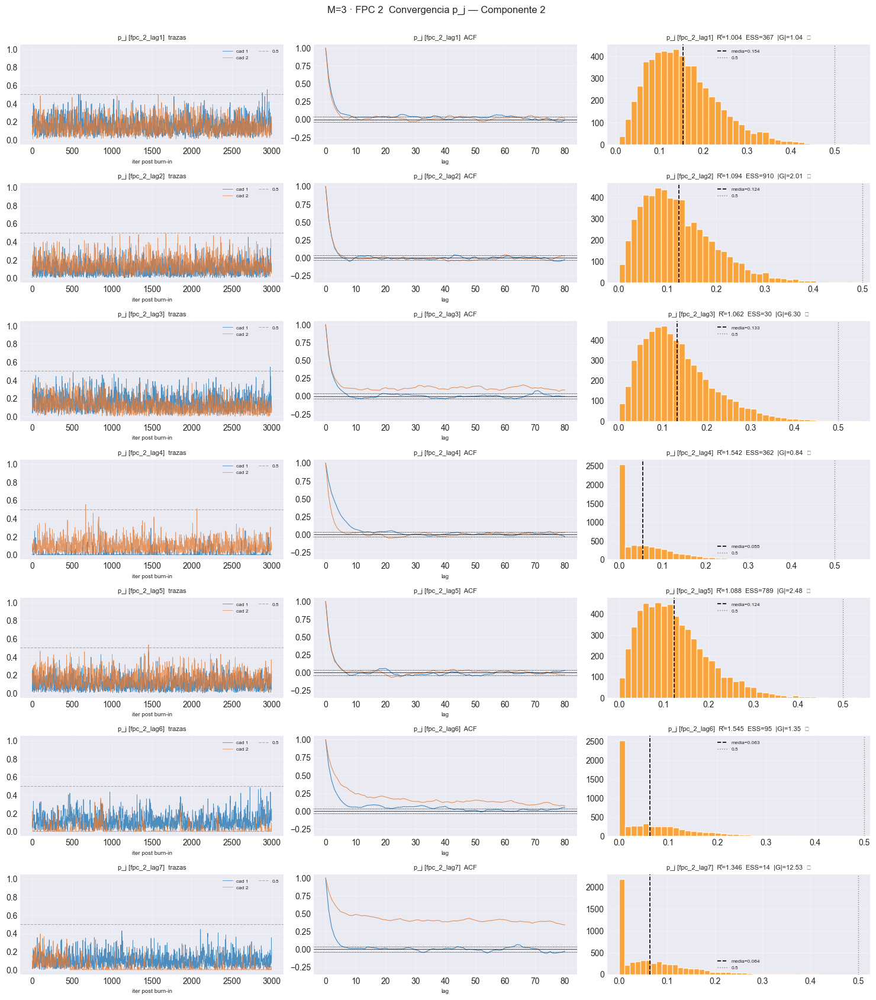

[plot_convergence_bj[FPC 3]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.5s  fpc_3_lag1  rhat=1.000  ess_min=1314  |G|=1.04  ✓
  2/7 (28.6%) t=0.1s eta=0.4s  fpc_3_lag2  rhat=1.000  ess_min=2671  |G|=1.08  ✓
  3/7 (42.9%) t=0.2s eta=0.3s  fpc_3_lag3  rhat=1.000  ess_min=3000  |G|=0.21  ✓
  4/7 (57.1%) t=0.3s eta=0.2s  fpc_3_lag4  rhat=1.000  ess_min=3000  |G|=1.16  ✓
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_3_lag5  rhat=1.000  ess_min=1149  |G|=0.59  ✓
  6/7 (85.7%) t=0.4s eta=0.1s  fpc_3_lag6  rhat=1.000  ess_min=1647  |G|=1.82  ✓
  7/7 (100.0%) t=0.5s eta=0.0s  fpc_3_lag7  rhat=1.000  ess_min=2734  |G|=1.39  ✓
[plot_convergence_bj[FPC 3]] listo: 7 pasos en 4.5s  0/7 sin converger


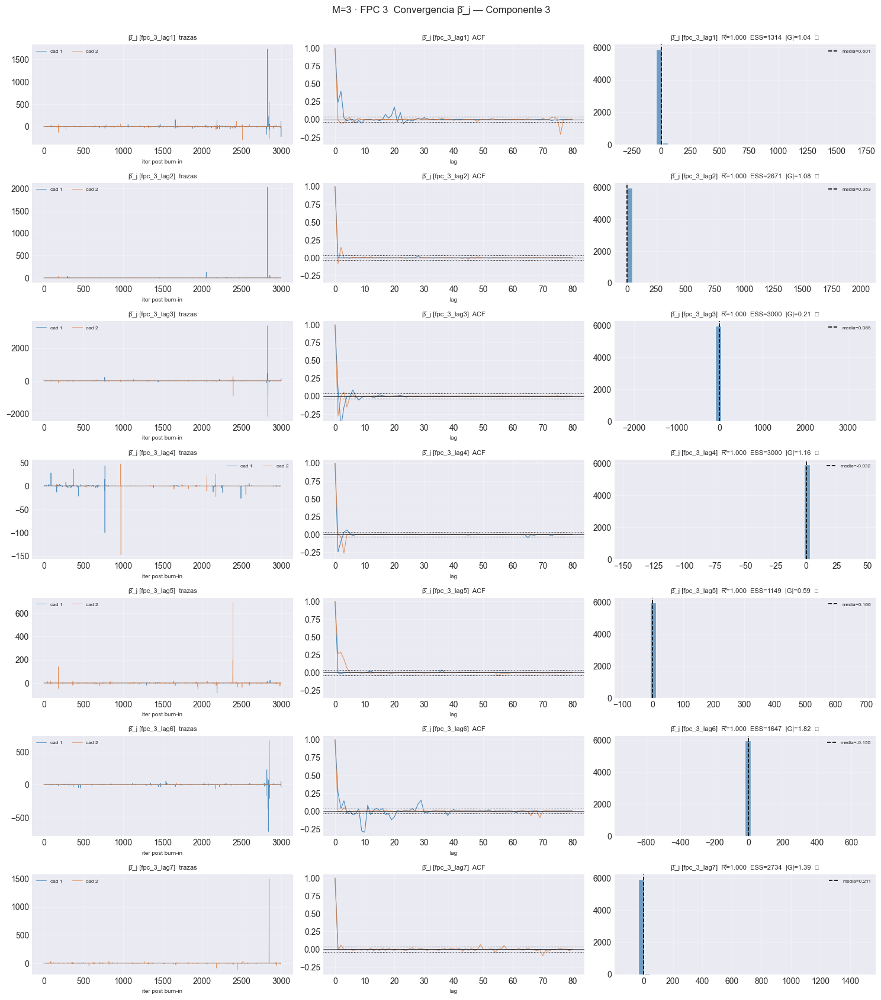

[plot_convergence_pj[FPC 3]] inicio (7 pasos)
  1/7 (14.3%) t=0.1s eta=0.4s  fpc_3_lag1  rhat=1.054  ess_min=818  |G|=2.05  ✗
  2/7 (28.6%) t=0.1s eta=0.3s  fpc_3_lag2  rhat=1.001  ess_min=464  |G|=0.31  ✓
  3/7 (42.9%) t=0.2s eta=0.2s  fpc_3_lag3  rhat=1.047  ess_min=118  |G|=5.07  ✗
  4/7 (57.1%) t=0.2s eta=0.2s  fpc_3_lag4  rhat=1.050  ess_min=10  |G|=11.59  ✗
  5/7 (71.4%) t=0.3s eta=0.1s  fpc_3_lag5  rhat=1.631  ess_min=533  |G|=2.01  ✗
  6/7 (85.7%) t=0.3s eta=0.1s  fpc_3_lag6  rhat=1.889  ess_min=64  |G|=6.48  ✗
  7/7 (100.0%) t=0.4s eta=0.0s  fpc_3_lag7  rhat=1.755  ess_min=101  |G|=5.54  ✗
[plot_convergence_pj[FPC 3]] listo: 7 pasos en 4.5s  6/7 sin converger


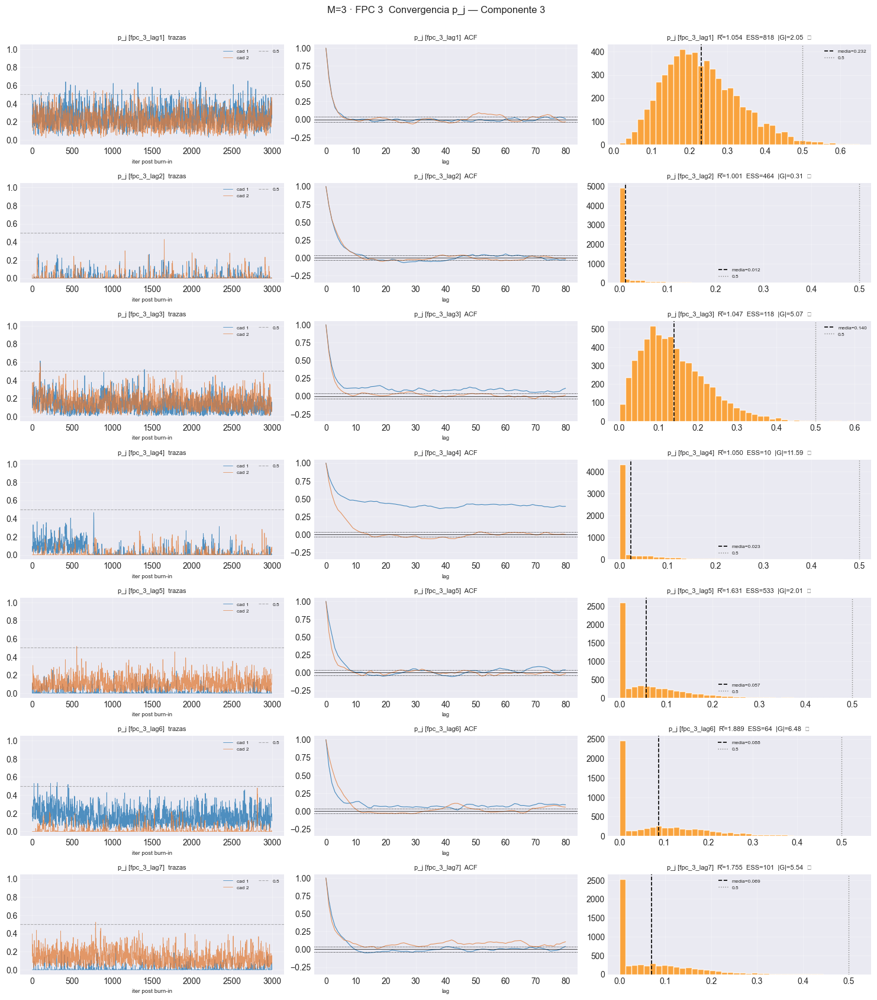

In [12]:
# Traza | ACF | posterior, con las métricas anotadas. beta_j va promediado
# sobre átomos (invariante a la permutación de etiquetas).
# verbose=True saca Rhat/ESS/Geweke por covariable a la consola: son las mismas
# cifras que van en el título de cada panel, pero legibles y copiables sin
# tener que leerlas de la figura.
for M in M_OK:
    e = EST[M]
    print(f"== M={M} " + "=" * 46)
    for k in e["models_chains"]:
        fpc  = e["component_idx"][k] + 1
        feat = e["models_chains"][k][0].feature_names_
        plot_convergence_bj(
            e["models_chains"], k, e["burn"], e["n_iter"], feature_names=feat,
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"44_conv_bj_k{fpc}.png"),
            verbose=True)
        plt.show()
        plot_convergence_pj(
            e["models_chains"], k, e["burn"], e["n_iter"], feature_names=feat,
            title_prefix=f"M={M} · FPC {fpc}",
            save_path=str(e["paths"]["out_report"] / f"45_conv_pj_k{fpc}.png"),
            verbose=True)
        plt.show()

## 6. Probabilidades posteriores de inclusión

Qué rezagos propios selecciona el modelo. En datos reales **no hay estructura
verdadera** contra la cual contrastar (el §6.1 del 101 se omite): se reporta la
PIP y su media por punto, `pip_media`, sin especificidad ni AUC.

In [13]:
for M in M_OK:
    e = EST[M]
    pip_df = matriz_pip(e["models_chains"], e["burn"],
                        component_idx=e["component_idx"], verbose=True)
    pip_df.to_csv(e["paths"]["out_report"] / "46_pip.csv")
    e["pip_df"] = pip_df

    cols_pip = [c for c in pip_df.columns if not c.endswith("_sd")]
    display(pip_df.style
        .background_gradient(subset=cols_pip, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} - P(gamma_j = 1 | datos), inclusión global, "
                     "media entre cadenas +- sd"))

    sd_cols = [c for c in pip_df.columns if c.endswith("_sd")]
    sd_max = float(pip_df[sd_cols].to_numpy().max()) if sd_cols else float("nan")
    e["pip_sd_max"] = sd_max
    e["pip_media"] = float(pip_df[cols_pip].to_numpy().mean())
    print(f"[M={M}] dispersión máxima entre cadenas: {sd_max:.3f}"
          + ("   ! las cadenas discrepan sobre la selección" if sd_max > 0.15
             else "   OK las cadenas coinciden"))

[matriz_pip] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 7 variables, PIP en [0.130, 1.000]
[matriz_pip] listo: 1 pasos en 0.0s  tabla 7x2


,FPC 1,FPC 1_sd
variable,,
fpc_1_lag1,1.000,0.000
fpc_1_lag2,1.000,0.000
fpc_1_lag3,0.130,0.152
fpc_1_lag4,1.000,0.000
fpc_1_lag5,0.555,0.202
fpc_1_lag6,1.000,0.000
fpc_1_lag7,0.691,0.438


[M=1] dispersión máxima entre cadenas: 0.438   ! las cadenas discrepan sobre la selección
[matriz_pip] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 7 variables, PIP en [0.130, 1.000]
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 7 variables, PIP en [0.512, 1.000]
[matriz_pip] listo: 2 pasos en 0.0s  tabla 14x4


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd
variable,,,,
fpc_1_lag1,1.000,0.000,nan,nan
fpc_1_lag2,1.000,0.000,nan,nan
fpc_1_lag3,0.130,0.152,nan,nan
fpc_1_lag4,1.000,0.000,nan,nan
fpc_1_lag5,0.555,0.202,nan,nan
fpc_1_lag6,1.000,0.000,nan,nan
fpc_1_lag7,0.691,0.438,nan,nan
fpc_2_lag1,nan,nan,1.000,0.000
fpc_2_lag2,nan,nan,1.000,0.000


[M=2] dispersión máxima entre cadenas: nan   OK las cadenas coinciden
[matriz_pip] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 7 variables, PIP en [0.130, 1.000]
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 7 variables, PIP en [0.512, 1.000]
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 7 variables, PIP en [0.012, 1.000]
[matriz_pip] listo: 3 pasos en 0.0s  tabla 21x6


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd
variable,,,,,,
fpc_1_lag1,1.000,0.000,nan,nan,nan,nan
fpc_1_lag2,1.000,0.000,nan,nan,nan,nan
fpc_1_lag3,0.130,0.152,nan,nan,nan,nan
fpc_1_lag4,1.000,0.000,nan,nan,nan,nan
fpc_1_lag5,0.555,0.202,nan,nan,nan,nan
fpc_1_lag6,1.000,0.000,nan,nan,nan,nan
fpc_1_lag7,0.691,0.438,nan,nan,nan,nan
fpc_2_lag1,nan,nan,1.000,0.000,nan,nan
fpc_2_lag2,nan,nan,1.000,0.000,nan,nan


[M=3] dispersión máxima entre cadenas: nan   OK las cadenas coinciden


## 7. Verificación muestreador ↔ predictor

`inEout` es $E[y\mid x]$ dentro de muestra tal como la calcula MATLAB en cada
iteración. Debe coincidir con lo que el predictor de Python reconstruye a
partir de las mismas trazas. Es la única prueba directa de que ambos lados
interpretan las trazas igual, y falla ruidosamente si el contrato se rompe.

Se corre **en cada $M$**: el contrato depende de $p$, y el punto $M=1$ es
justamente donde MATLAB colapsa la dimensión de covariables al guardar.

In [14]:
print("corr(inEout, predict) sobre el bloque de entrenamiento:")
ok_global = True
for M in M_OK:
    e = EST[M]
    ok = True
    print(f"-- M={M} --")
    for k in e["models_chains"]:
        for c in sorted(e["models_chains"][k]):
            m = e["models_chains"][k][c]
            mu_tr = m.predict(e["dfs_train"][k])
            inE   = m.traces["inEout"][m.burn:].mean(axis=0)
            corr  = float(np.corrcoef(inE, mu_tr)[0, 1])
            dif   = float(np.abs(inE - mu_tr).max())
            ok &= corr > 0.999
            print(f"  FPC {e['component_idx'][k]+1} cadena{c+1}: corr={corr:.6f}  "
                  f"|dif|max={dif:.4f}" + ("" if corr > 0.999 else "   ! REVISAR"))
    e["contrato_ok"] = ok
    ok_global &= ok
    print(f"  {'OK' if ok else 'X'} contrato sampler<->predictor "
          f"{'verificado' if ok else 'FALLA'} en M={M}")

print(f"\n{'OK contrato verificado en todo el barrido' if ok_global else 'X el contrato falla'}")

corr(inEout, predict) sobre el bloque de entrenamiento:
-- M=1 --
  FPC 1 cadena1: corr=1.000000  |dif|max=0.0001
  FPC 1 cadena2: corr=1.000000  |dif|max=0.0001
  OK contrato sampler<->predictor verificado en M=1
-- M=2 --
  FPC 1 cadena1: corr=1.000000  |dif|max=0.0001
  FPC 1 cadena2: corr=1.000000  |dif|max=0.0001
  FPC 2 cadena1: corr=1.000000  |dif|max=0.0000
  FPC 2 cadena2: corr=1.000000  |dif|max=0.0000
  OK contrato sampler<->predictor verificado en M=2
-- M=3 --
  FPC 1 cadena1: corr=1.000000  |dif|max=0.0001
  FPC 1 cadena2: corr=1.000000  |dif|max=0.0001
  FPC 2 cadena1: corr=1.000000  |dif|max=0.0000
  FPC 2 cadena2: corr=1.000000  |dif|max=0.0000
  FPC 3 cadena1: corr=1.000000  |dif|max=0.0000
  FPC 3 cadena2: corr=1.000000  |dif|max=0.0000
  OK contrato sampler<->predictor verificado en M=3

OK contrato verificado en todo el barrido


## 8. Comparación entre los puntos del barrido

| Cifra | Por qué es comparable entre $M$ |
|---|---|
| $\hat R$ máx, ESS mín, Geweke máx | son el **peor caso** sobre las variables de ese punto, no un promedio sobre un número de variables que cambia con $M$ |
| ocupación media de la mezcla | cuenta átomos, no depende de la dimensión |
| PIP media | proporción, acotada en $[0,1]$ |

In [15]:
filas = []
for M in M_OK:
    e   = EST[M]
    res = e["res_conv"]
    ocu = e["ocup_df"]

    fila = {
        "M": M,
        "experiment_id": e["eid"],
        "p_covariables": len(e["cov_por_componente"][0]),
        "n_variables_diag": int(res["n_variables"]),
        "rhat_max": float(res["rhat_max"]),
        "ess_min": float(res["ess_min"]),
        "geweke_max": float(res["geweke_max"]),
        "n_no_converge": int(res["n_no_converge"]),
        "converge": bool(res["todo_converge"]),
        "ocupacion_media": float(ocu["media"].mean()),
        "ocupacion_max": int(ocu["max"].max()),
        "N_trunc": int(ocu["N_trunc"].iloc[0]),
        "toca_truncamiento": bool(ocu["toca_truncamiento"].any()),
        "pip_sd_max": e["pip_sd_max"],
        "pip_media": e["pip_media"],
        "contrato_ok": bool(e["contrato_ok"]),
    }
    filas.append(fila)

barrido_df = pd.DataFrame(filas).set_index("M")
barrido_df.to_csv(PATH_BARRIDO / "80_convergencia_por_M.csv")

_fmt = {c: "{:.4f}" for c in ("rhat_max", "geweke_max", "pip_sd_max",
                              "pip_media") if c in barrido_df.columns}
_fmt.update({"ess_min": "{:.0f}", "ocupacion_media": "{:.2f}"})
display(barrido_df.style.format(_fmt, na_rep="-")
        .background_gradient(subset=["rhat_max"], cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn", vmin=0, vmax=500)
        .set_caption("Diagnóstico de muestreo a lo largo del barrido en M"))

,experiment_id,p_covariables,n_variables_diag,rhat_max,ess_min,geweke_max,n_no_converge,converge,ocupacion_media,ocupacion_max,N_trunc,toca_truncamiento,pip_sd_max,pip_media,contrato_ok
M,,,,,,,,,,,,,,,
1,real_nivel_v05_m01,7,14,1.1797,6,18.1261,10,False,24.15,40,40,True,0.4377,0.7679,True
2,real_nivel_v05_m02,7,28,1.5453,6,18.1261,18,False,20.07,40,40,True,-,-,True
3,real_nivel_v05_m03,7,42,1.8892,6,18.1261,24,False,18.17,40,40,True,-,-,True


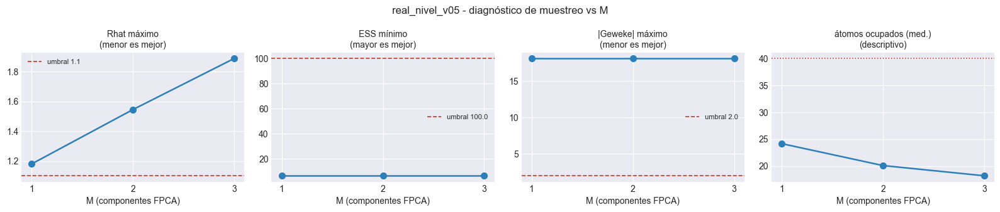

In [16]:
# Figura del barrido: cuatro paneles, todos con M en el eje x. Los umbrales van
# como línea horizontal para que la lectura no dependa de recordar cuáles son.
_Ms = list(barrido_df.index)
_um = EST[M_OK[0]]["res_conv"]["umbrales"]

paneles = [
    ("rhat_max",        "Rhat máximo",            _um["rhat"],   "menor es mejor"),
    ("ess_min",         "ESS mínimo",             _um["ess"],    "mayor es mejor"),
    ("geweke_max",      "|Geweke| máximo",        _um["geweke"], "menor es mejor"),
    ("ocupacion_media", "átomos ocupados (med.)", None,          "descriptivo"),
]

fig, axes = plt.subplots(1, len(paneles), figsize=(4.0 * len(paneles), 3.4),
                         squeeze=False)
for ax, (col, titulo, umbral, nota) in zip(axes[0], paneles):
    y = barrido_df[col].to_numpy(dtype=float)
    ax.plot(_Ms, y, "o-", lw=1.8, ms=7, color="#2c7fb8")
    if umbral is not None:
        ax.axhline(umbral, color="#c0392b", ls="--", lw=1.2,
                   label=f"umbral {umbral}")
        ax.legend(fontsize=8)
    if col == "ocupacion_media":
        ax.axhline(barrido_df["N_trunc"].iloc[0], color="#c0392b", ls=":", lw=1.2)
    ax.set_xticks(_Ms)
    ax.set_xlabel("M (componentes FPCA)")
    ax.set_title(f"{titulo}\n({nota})", fontsize=10)
fig.suptitle(f"{EXPERIMENT_BASE} - diagnóstico de muestreo vs M", fontsize=12)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "81_diagnostico_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

FPC,1,2,3
M,,,
1,24.15,-,-
2,24.15,15.99,-
3,24.15,15.99,14.36


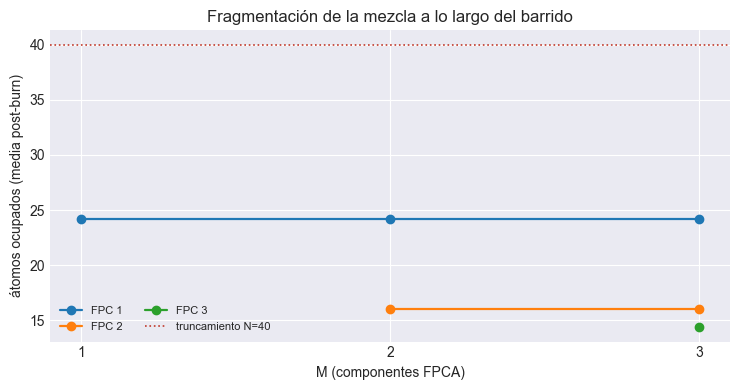

In [17]:
# Ocupación de la mezcla por M y componente: es la cifra que dice si al subir M
# el modelo parte la mezcla en más átomos. Se separa por FPC porque el promedio
# global esconde que sean las componentes NUEVAS las que se fragmentan.
ocup_todo = pd.concat([EST[M]["ocup_df"] for M in M_OK], ignore_index=True)
ocup_todo.to_csv(PATH_BARRIDO / "82_ocupacion_por_M.csv", index=False)

piv = ocup_todo.groupby(["M", "FPC"])["media"].mean().unstack("FPC")
display(piv.style.format("{:.2f}", na_rep="-")
        .background_gradient(cmap="RdYlGn_r", axis=None)
        .set_caption("Átomos ocupados (media post-burn) por M y componente FPCA"))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
for fpc in piv.columns:
    s = piv[fpc].dropna()
    ax.plot(s.index, s.to_numpy(), "o-", lw=1.6, ms=6, label=f"FPC {int(fpc)}")
_Ntr = int(ocup_todo["N_trunc"].iloc[0])
ax.axhline(_Ntr, color="#c0392b", ls=":", lw=1.2, label=f"truncamiento N={_Ntr}")
ax.set_xticks(list(piv.index))
ax.set_xlabel("M (componentes FPCA)")
ax.set_ylabel("átomos ocupados (media post-burn)")
ax.set_title("Fragmentación de la mezcla a lo largo del barrido")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "82_ocupacion_por_M.png", dpi=150, bbox_inches="tight")
plt.show()

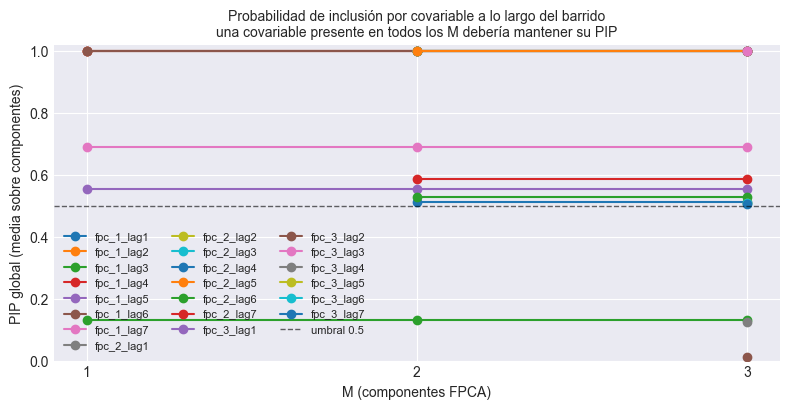

Las covariables que sólo existen a partir de cierto M aparecen con la línea cortada: no es un hueco de datos, es que esa covariable no existe en los puntos más chicos del barrido.


In [18]:
# PIP: una fila por (M, componente FPCA, covariable). Las matrices de distintos
# M no se apilan tal cual porque no comparten ni filas ni columnas, así que se
# pasan a formato largo, que sí admite la comparación.
partes = []
for M in M_OK:
    pip  = EST[M]["pip_df"]
    cols = [c for c in pip.columns if not c.endswith("_sd")]
    largo = pip[cols].stack().rename("pip").reset_index()
    largo.columns = ["covariable", "componente", "pip"]
    largo.insert(0, "M", M)
    partes.append(largo)

pip_largo = pd.concat(partes, ignore_index=True)
pip_largo.to_csv(PATH_BARRIDO / "83_pip_por_M.csv", index=False)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for cov, g in pip_largo.groupby("covariable"):
    s = g.groupby("M")["pip"].mean()
    ax.plot(s.index, s.to_numpy(), "o-", lw=1.5, ms=6, label=str(cov))
ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.6, label="umbral 0.5")
ax.set_xticks(list(M_OK))
ax.set_ylim(0, 1.02)
ax.set_xlabel("M (componentes FPCA)")
ax.set_ylabel("PIP global (media sobre componentes)")
ax.set_title("Probabilidad de inclusión por covariable a lo largo del barrido\n"
             "una covariable presente en todos los M debería mantener su PIP",
             fontsize=10)
ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / "83_pip_por_M.png", dpi=150, bbox_inches="tight")
plt.show()

print("Las covariables que sólo existen a partir de cierto M aparecen con la "
      "línea cortada: no es un hueco de datos, es que esa covariable no existe "
      "en los puntos más chicos del barrido.")

In [19]:
# == Veredicto del barrido ===================================================
print("=" * 66)
print(f"  BARRIDO {EXPERIMENT_BASE}   ·   M evaluados: {list(M_OK)}")
print("=" * 66)
for M in M_OK:
    f = barrido_df.loc[M]
    print(f"  M={M}  p={int(f['p_covariables'])}  "
          f"Rhatmax={f['rhat_max']:.3f}  ESSmin={f['ess_min']:.0f}  "
          f"ocup={f['ocupacion_media']:.1f}/{int(f['N_trunc'])}  "
          f"{'OK' if f['converge'] else 'X NO CONVERGE'}")

_no   = [int(M) for M in barrido_df.index if not barrido_df.loc[M, "converge"]]
_falt = sorted(set(M_FPCA_LIST) - set(M_OK))
print("-" * 66)
if _falt:
    print(f"! sin trazas todavía: M = {_falt}  -> correr psbp_fd_iteracion.m")
if _no:
    print(f"X NO convergen: M = {_no}. Excluirlos de la comparación de 24_04/24_05,")
    print("  o subir nsim/burn antes de leer su MISE como efecto de M.")
else:
    print("OK todo el barrido converge: las diferencias que 24_04 encuentre entre")
    print("   los M son atribuibles al modelo y no al muestreo.")

# Tendencia, sólo con al menos tres puntos: con dos, cualquier par define una
# recta y la pendiente no dice nada.
if len(M_OK) >= 3:
    _r = np.corrcoef(list(M_OK), barrido_df["rhat_max"].to_numpy())[0, 1]
    _e = np.corrcoef(list(M_OK), barrido_df["ess_min"].to_numpy())[0, 1]
    print(f"\ncorr(M, Rhatmax) = {_r:+.3f}   ·   corr(M, ESSmin) = {_e:+.3f}")
    if _r > 0.8 or _e < -0.8:
        print("  <- el muestreo se degrada monótonamente con M: parte de lo que")
        print("     24_04 atribuya a M sería esfuerzo de muestreo insuficiente.")
print("=" * 66)
print(f"Tablas y figuras cruzadas en {PATH_BARRIDO}  (archivos 80-83)")
print("Continuar con 24_04_evaluacion, declarando el mismo M_FPCA_LIST.")

  BARRIDO real_nivel_v05   ·   M evaluados: [1, 2, 3]
  M=1  p=7  Rhatmax=1.180  ESSmin=6  ocup=24.2/40  X NO CONVERGE
  M=2  p=7  Rhatmax=1.545  ESSmin=6  ocup=20.1/40  X NO CONVERGE
  M=3  p=7  Rhatmax=1.889  ESSmin=6  ocup=18.2/40  X NO CONVERGE
------------------------------------------------------------------
X NO convergen: M = [1, 2, 3]. Excluirlos de la comparación de 24_04/24_05,
  o subir nsim/burn antes de leer su MISE como efecto de M.

corr(M, Rhatmax) = +1.000   ·   corr(M, ESSmin) = +nan
  <- el muestreo se degrada monótonamente con M: parte de lo que
     24_04 atribuya a M sería esfuerzo de muestreo insuficiente.
Tablas y figuras cruzadas en C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_nivel_v05_barrido_M  (archivos 80-83)
Continuar con 24_04_evaluacion, declarando el mismo M_FPCA_LIST.


c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
